# Optimización de packaging y logística — Bonsai Corp

**Data Challenge de AlixPartners.** Consolidación del catálogo de cajas de 427 SKUs.

---

### Nota sobre este notebook

El ETL, el análisis exploratorio y el estudio de dimensiones se desarrollaron en Colab y
están tal cual se ejecutaron.

El **motor de optimización final** (enumeración exhaustiva de geometrías + MILP exacto) se
desarrolló y ejecutó **en Spyder, como scripts de Python separados**, porque necesitaba
correr durante horas, escribir resultados intermedios a disco y apoyarse en un módulo
propio (`bonsai_core.py`) con la evaluación geométrica y el costeo. Acá está integrado en
el notebook **solo para presentación**: las celdas del motor no corren en Colab, porque
dependen de rutas locales y del módulo `bonsai_core`.

Las versiones anteriores del motor —heurística con Monte Carlo y grid search— quedaron
obsoletas al llegar a la formulación exacta y no se incluyen.


# Datos del problema


## Analisis del DF

**Catalogo_productos** — ID: codigo_producto + caja_tipo_id
* tipo_proyecto: indica lo esporádico del producto (estacional o estable)
* peso_neto_caja: peso de la caja para cada producto
* tamaño_paquete: cantidad de paquetes por su peso. **Es la única columna sin errores, se toma como fuente confiable**
* cantidad_paquetes: cantidad de paquetes por caja de un producto. **Tiene filas vacías**
* peso_neto_paquete: peso de cada paquete individual dentro de la caja. **Tiene filas vacías**

Criterio de la tabla: pesos en kg con dos decimales; productos y cajas como enteros.


**Especificaciones_caja** — ID: caja_tipo_id
* caja_grosor_mm: grosor de las cajas en mm. **Reporta valores con la unidad dentro de la celda y mezcla comas con puntos**

* Dimensiones externas en mm → volumen de caja. **Mezcla comas y puntos**
  * caja_exterior_largo ; caja_exterior_ancho ; caja_exterior_alto

* Dimensiones internas en mm → volumen ocupado por el producto (se toma como un líquido que ocupa el 100 % de la caja). **Mezcla comas y puntos**
  * caja_interior_largo ; caja_interior_ancho ; caja_interior_alto

* Dimensiones de pallet. **No tienen el .0 al final como el resto**
  * pallet_alto ; pallet_ancho ; pallet_largo

* Distribución de cajas. **Algunos valores no son enteros y faltan datos de cantidad de cajas totales**
  * cantidad_cajas_alto ; cantidad_cajas_largo ; cantidad_cajas_ancho ; cantidad_cajas_total

* utilizacion: porcentaje de espacio ocupado del pallet. **Mezcla comas y puntos**

Criterio de la tabla: medidas de distancia en mm con un decimal.


**Procurement_cajas** — ID: caja_tipo_id
* Volumen tipo planta: volumen de cajas necesarias. **Sin inconsistencias detectadas**
  * volumen_tipo_planta_buenos_aires ; volumen_tipo_planta_curitiba ; volumen_tipo_planta_santiago ; volumen_tipo_planta_monterrey ; volumen_tipo_planta_bakersfield

* Costo tipo planta:
  * costo_unitario_base: costo de cada caja. **Mezcla comas y puntos, y cantidad heterogénea de decimales. Se unifica a 2 decimales**

  * costo_total_base: suma de todos los costos de cada caja

  * costo_unitario_planta_*: costo de una caja en cada planta, con el descuento ya aplicado. **Muchas filas cargadas como ERROR; se reconstruyen como precio unitario base × descuento de esa planta. Se unifica a 3 decimales**
    * costo_unitario_planta_buenos_aires ; costo_unitario_planta_curitiba ; costo_unitario_planta_santiago ; costo_unitario_planta_monterrey ; costo_unitario_planta_bakersfield

  * descuento_planta_*: lo que se suma o resta al precio en cada planta. **Notación inconsistente: aparece como +a%, − a %, con espacios sobrantes. Se unifica al formato ±a%**
    * descuento_planta_buenos_aires ; descuento_planta_curitiba ; descuento_planta_santiago ; descuento_planta_monterrey ; descuento_planta_bakersfield

* Costo_por_pallet: valor agregado para todos los productos (offset)


**Operaciones_planta** — ID: codigo_producto
* Volumen de venta: a qué canal se vendió el producto y el volumen total. **Se contrasta que la suma de los canales dé el total**
  * volumen_producto_canal_servicios_comida ; volumen_producto_canal_minorista ; volumen_producto_canal_cadenas_corporativas ; volumen_producto_canal_otros ; volumen_producto_total

* Volumen de producción: cantidad almacenada de producto en cada planta
  * volumen_producto_planta_buenos_aires ; volumen_producto_planta_curitiba ; volumen_producto_planta_santiago ; volumen_producto_planta_monterrey ; volumen_producto_planta_bakersfield

* Cantidad de pallets: en cuántos están almacenados estos productos en cada fábrica. **Se contrasta que la suma por planta dé el total**
  * cantidad_pallets_planta_buenos_aires ; cantidad_pallets_planta_curitiba ; cantidad_pallets_planta_santiago ; cantidad_pallets_planta_monterrey ; cantidad_pallets_planta_bakersfield ; cantidad_pallets_total

* Costo total por planta: producción más almacenamiento. **Cantidad excesiva de decimales no significativos; se unifica a 2 decimales**
  * costo_total_planta_buenos_aires ; costo_total_planta_curitiba ; costo_total_planta_santiago ; costo_total_planta_monterrey ; costo_total_planta_bakersfield

* Costo de pallets: cuánto cuesta tener esos pallets en cada fábrica. **Se contrasta la suma por planta contra el total, y se divide el costo por la cantidad de pallets para ver el costo unitario resultante**
  * costo_pallets_planta_buenos_aires ; costo_pallets_planta_curitiba ; costo_pallets_planta_santiago ; costo_pallets_planta_monterrey ; costo_pallets_planta_bakersfield ; costo_pallets_total

* costo_total: costo total del producto, producción más almacenamiento. **Se unifica a 2 decimales y se contrasta contra la suma de los costos por planta**


# ETL - DF

In [1]:
import numpy as np
import pandas as pd
from google.colab import files
import io
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#Cargo mis DF
df_cat = pd.read_csv("/content/drive/MyDrive/Alliexpress/catalogo_productos.csv") #id: caja_tipo_id + codigo_producto
df_esp = pd.read_csv("/content/drive/MyDrive/Alliexpress/especificaciones_cajas.csv") #id: caja_tipo_id
df_op = pd.read_csv("/content/drive/MyDrive/Alliexpress/operaciones_planta.csv") #id : codigo_producto
df_proc = pd.read_csv("/content/drive/MyDrive/Alliexpress/procurement_cajas.csv") #id : caja_tipo_id

Este bloque se encarga de la limpieza de columnas en el df catalogo de productos. Se detecto:

-Error o falta de datos en cantidad_paquetes y peso_neto_caja a partir del dato tamaño_paquete, que esta escrito de forma "cantidad de paquetes por caja" X "PESO KG"



In [3]:
#CODIGO DE LIMPIEZA 1 : CATALOGO DE PRODUCTOS
import pandas as pd
import numpy as np
import re

print("--- FASE 1: AUDITORÍA Y LIMPIEZA DE CATÁLOGO ---")

# 1. Función Regex: Extrae la "verdad absoluta" del texto fila por fila
def extraer_verdad(texto):
    if pd.isna(texto):
        return np.nan, np.nan
    # Busca patrones universales (ej: "5 X 2,5 KG" o "13x0.75"), capturando cantidad y peso
    match = re.search(r'(\d+)\s*[xX]\s*(\d+(?:[.,]\d+)?)', str(texto))
    if match:
        cant = float(match.group(1))
        # Reemplaza comas por puntos para que Python lo entienda como decimal
        peso = float(match.group(2).replace(',', '.'))
        return cant, peso
    return np.nan, np.nan

# 2. Aplicamos el motor de extracción a todo el catálogo
df_cat[['cant_limpia', 'peso_limpio']] = df_cat['tamaño_paquete'].apply(
    lambda x: pd.Series(extraer_verdad(x))
)

# 3. Resolución de Conflictos y Relleno de Huecos
# Sobrescribimos las columnas numéricas rotas con los datos limpios y estandarizados
df_cat['cantidad_paquetes'] = df_cat['cant_limpia'].astype(int) # Forzamos a número entero
df_cat['peso_neto_paquete'] = df_cat['peso_limpio']

# 4. Sincronización Matemática
# Recalculamos el peso de la caja para eliminar cualquier viejo error de tipeo
df_cat['peso_neto_caja'] = df_cat['cantidad_paquetes'] * df_cat['peso_neto_paquete']

# 5. Limpieza de andamiaje temporal
df_cat = df_cat.drop(columns=['cant_limpia', 'peso_limpio'])

# Validación final
nulos_restantes = df_cat[['cantidad_paquetes', 'peso_neto_paquete', 'peso_neto_caja']].isnull().sum().sum()
print(f"-> Limpieza completada. Errores matemáticos y huecos restantes: {nulos_restantes}")
print(df_cat[['codigo_producto', 'tamaño_paquete', 'cantidad_paquetes', 'peso_neto_paquete', 'peso_neto_caja']].head())

--- FASE 1: AUDITORÍA Y LIMPIEZA DE CATÁLOGO ---
-> Limpieza completada. Errores matemáticos y huecos restantes: 0
  codigo_producto tamaño_paquete  cantidad_paquetes  peso_neto_paquete  \
0          BR0001     5 X 2,5 KG                  5               2.50   
1          BR0002   13 X 0,75 KG                 13               0.75   
2          BR0003   13 X 0,75 KG                 13               0.75   
3          BR0004    9 X 1,25 KG                  9               1.25   
4          BR0005   13 X 0,75 KG                 13               0.75   

   peso_neto_caja  
0           12.50  
1            9.75  
2            9.75  
3           11.25  
4            9.75  


Codigo de limpieza del df especificaciones_caja

- Quita basura de texto de la columna caja_grosor_mm; donde habia problemas de tipeo con unidades dentro de la columna y algunos errores entre comas y puntos.

- Estandarizamos a la misma cantidad de decimales en todas las columnas

- Recalculo de cantidad_cajas_totales para llenar huecos en el df, a partir de dimensiones del pallet y dimensioens internas + grosor

In [4]:
# CODIGO DE LIMPIEZA 2: ESPECIFICACIONES_CAJA

import pandas as pd
import numpy as np

print("--- FASE 2: LIMPIEZA DE ESPECIFICACIONES FÍSICAS Y APLICACIÓN DE HIPÓTESIS FLUIDA ---\n")

# Asumimos que tu dataframe se llama df_esp
# df_esp = pd.read_csv('especificaciones_cajas.csv')

# 1. Limpieza de 'caja_grosor_mm': Remover letras (como "mm"), espacios y forzar el punto decimal
df_esp['caja_grosor_mm'] = df_esp['caja_grosor_mm'].astype(str)\
    .str.replace(r'[a-zA-Z\s]', '', regex=True)\
    .str.replace(',', '.')\
    .astype(float)

# 2. Estandarización a 1 decimal: Todas las medidas físicas en milímetros
medidas_fisicas_mm = [
    'caja_grosor_mm',
    'caja_interior_largo', 'caja_interior_ancho', 'caja_interior_alto',
    'caja_exterior_largo', 'caja_exterior_ancho', 'caja_exterior_alto',
    'pallet_alto', 'pallet_ancho', 'pallet_largo'
]
# Forzamos todo a float (esto soluciona lo de los pallets que no tenían el .0) y redondeamos a 1
df_esp[medidas_fisicas_mm] = df_esp[medidas_fisicas_mm].astype(float).round(1)

# 3. Limpieza de Utilización (asegurarnos de que no haya comas traicioneras escondidas)
if df_esp['utilizacion'].dtype == 'object':
    df_esp['utilizacion'] = df_esp['utilizacion'].astype(str).str.replace(',', '.').astype(float)

# 4. Distribución de Cajas: Forzar a números enteros discretos (int)
cajas_dimensionales = ['cantidad_cajas_alto', 'cantidad_cajas_largo', 'cantidad_cajas_ancho']
# Llenamos nulos con 0 preventivamente para que el casting a entero no falle
df_esp[cajas_dimensionales] = df_esp[cajas_dimensionales].fillna(0).astype(int)

# Re-calculamos la 'cantidad_cajas_total' desde cero usando la física pura
# Esto soluciona los datos faltantes (NaN) que detectaste en esa columna
df_esp['cantidad_cajas_total'] = (
    df_esp['cantidad_cajas_alto'] *
    df_esp['cantidad_cajas_largo'] *
    df_esp['cantidad_cajas_ancho']
)

# 5. NUEVA HIPÓTESIS: Volumen como Fluido (100% ocupación interna)
# Calculamos el volumen del producto neto en mm³ en base a la caja interna
df_esp['volumen_producto_interno_mm3'] = (
    df_esp['caja_interior_largo'] *
    df_esp['caja_interior_ancho'] *
    df_esp['caja_interior_alto']
).round(1)

print("-> Limpieza completada con éxito. Las medidas tienen 1 decimal estricto y las cajas son enteros.")
print("\n-> Muestra de las dimensiones del Pallet y Volumen Interno recalculado:\n")
columnas_vista = ['caja_tipo_id', 'caja_grosor_mm', 'pallet_alto', 'cantidad_cajas_total', 'volumen_producto_interno_mm3']
print(df_esp[columnas_vista].head())

--- FASE 2: LIMPIEZA DE ESPECIFICACIONES FÍSICAS Y APLICACIÓN DE HIPÓTESIS FLUIDA ---

-> Limpieza completada con éxito. Las medidas tienen 1 decimal estricto y las cajas son enteros.

-> Muestra de las dimensiones del Pallet y Volumen Interno recalculado:

                       caja_tipo_id  caja_grosor_mm  pallet_alto  \
0  02cf77de65b70dd77905e2e33d78478f             2.7       1800.0   
1  082c1cdb42b1abd201403ca33ca11ef0             4.1       1800.0   
2  0835ff365412a67b720a19713ec250f3             4.1       1800.0   
3  0b72571a5bb7429ce7de424547e8d27d             4.1       1800.0   
4  10c5f9edbe2c87186bcdeb991fe8d902             4.6       1800.0   

   cantidad_cajas_total  volumen_producto_interno_mm3  
0                    36                    34023720.0  
1                    72                    17951976.0  
2                    48                    30690088.0  
3                    72                    19208904.0  
4                    56                    21833280.0

Segundo bloque de analisis de especificacioes_caja

- Se detecto una discrepancia entre el volumen externo de las cajas y el obtenido a partir de la dimension interna + grosor reportado. Como las dimensiones internas se toman como el espacio irreductible ocupado por el producto, se toman esto como los reales y a partir de esto, se calcula el volumen externo real. Trabajaremos con esa cantidad

Dada la naturaleza del error (0.4)mm tiene pinta de haber sido algun error de redondeo para abajo a una cifra mas de lo relevante

In [5]:
#Segundo chequeo de las dimensiones de las cajas. Discrepancia entre volumen externo e interno:

import pandas as pd
import numpy as np

# Asumimos que df_esp ya está limpio y cargado en tu entorno
print("--- AUDITORÍA FÍSICA: ERROR ABSOLUTO (MÓDULO) SOBRE DF_ESP ---\n")

# Calculamos las dimensiones exteriores teóricas mínimas (Interior + 2*Grosor)
df_esp['teo_ext_largo'] = df_esp['caja_interior_largo'] + (2 * df_esp['caja_grosor_mm'])
df_esp['teo_ext_ancho'] = df_esp['caja_interior_ancho'] + (2 * df_esp['caja_grosor_mm'])
df_esp['teo_ext_alto']  = df_esp['caja_interior_alto'] + (2 * df_esp['caja_grosor_mm'])

# Calculamos el error absoluto (Módulo)
df_esp['diff_abs_largo'] = abs(df_esp['caja_exterior_largo'] - df_esp['teo_ext_largo']).round(2)
df_esp['diff_abs_ancho'] = abs(df_esp['caja_exterior_ancho'] - df_esp['teo_ext_ancho']).round(2)
df_esp['diff_abs_alto']  = abs(df_esp['caja_exterior_alto'] - df_esp['teo_ext_alto']).round(2)

# Imprimimos las estadísticas
print("Estadísticas del desvío en milímetros:")
print(df_esp[['diff_abs_largo', 'diff_abs_ancho', 'diff_abs_alto']].describe())

print("\nTop 5 cajas con mayor diferencia absoluta en el Largo:")
cols_fisica = ['caja_tipo_id', 'caja_grosor_mm', 'caja_interior_largo', 'caja_exterior_largo', 'diff_abs_largo']
print(df_esp.sort_values(by='diff_abs_largo', ascending=False)[cols_fisica].head(5))

--- AUDITORÍA FÍSICA: ERROR ABSOLUTO (MÓDULO) SOBRE DF_ESP ---

Estadísticas del desvío en milímetros:
       diff_abs_largo  diff_abs_ancho  diff_abs_alto
count      204.000000           204.0          204.0
mean         0.066667             0.0            0.0
std          0.149438             0.0            0.0
min          0.000000             0.0            0.0
25%          0.000000             0.0            0.0
50%          0.000000             0.0            0.0
75%          0.000000             0.0            0.0
max          0.400000             0.0            0.0

Top 5 cajas con mayor diferencia absoluta en el Largo:
                        caja_tipo_id  caja_grosor_mm  caja_interior_largo  \
0   02cf77de65b70dd77905e2e33d78478f             2.7                395.0   
11  162c41fa859810e889efa37f867819bb             2.7                395.0   
55  4c00c9ca639e09b29ebaf3d4ce15c111             2.7                395.0   
67  5752498adef915345dabc54b32edf146             2.7    

Aca simplemente corrigo el mismo df, asi la columna es fiable

In [6]:
# =====================================================================
# BLOQUE 1.5: CORRECCIÓN DE DIMENSIONES EXTERIORES (df_esp)
# =====================================================================
print("\n--- CORRECCIÓN DE DIMENSIONES EXTERIORES (df_esp) ---\n")

# 1. Calculamos el largo exterior teórico exacto (Interior + 2 * Grosor)
df_esp['teo_ext_largo'] = df_esp['caja_interior_largo'] + (2 * df_esp['caja_grosor_mm'])

# 2. Corregimos la columna original 'caja_exterior_largo'
# Reemplazamos los datos de catálogo con la física pura y redondeamos a 1 decimal
df_esp['caja_exterior_largo'] = df_esp['teo_ext_largo'].round(1)

# 3. Verificamos que el error haya desaparecido
df_esp['diff_abs_largo_post'] = abs(df_esp['caja_exterior_largo'] - df_esp['teo_ext_largo']).round(2)

print("Estadísticas del desvío en el Largo DESPUÉS de la corrección:")
print(df_esp['diff_abs_largo_post'].describe())
print("\n-> ¡Éxito! La columna 'caja_exterior_largo' ha sido rectificada matemáticamente.")

# Limpieza de columnas temporales
df_esp = df_esp.drop(columns=['teo_ext_largo', 'teo_ext_ancho', 'teo_ext_alto',
                              'diff_abs_largo', 'diff_abs_ancho', 'diff_abs_alto',
                              'diff_abs_largo_post'], errors='ignore')


--- CORRECCIÓN DE DIMENSIONES EXTERIORES (df_esp) ---

Estadísticas del desvío en el Largo DESPUÉS de la corrección:
count    204.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: diff_abs_largo_post, dtype: float64

-> ¡Éxito! La columna 'caja_exterior_largo' ha sido rectificada matemáticamente.


Tercer chequeo de especificaciones de cajas; quiero ver la utilizacion de pallet y si coincide con la reportada

-Se detecto que para que se de la utilizacion reportada, la empresa anteriormente no tenia ninguna regla de ordenamiento de acjas de pallets. Por grados de libertad tenemos muchas posibilidades. Conseguimos el numeo de utilizacion reportado para el 83% de cajas si se alinean de manera estandar (cara larga del pallet con corta de la caja).

El restante de cajas pudimos ver que se explican si, aun manteniendo la regla, se apilaban ccon un exceo en las dimensiones del pallet. Las cajas sobresaldrian 0.8mm del borde del pallet

In [7]:
#ERROR EN UTILIZACION, CALCULO DEL METOOD DE APILADO ANTIGUO

import pandas as pd
import numpy as np

print("--- AUDITORÍA V3: DELTA DE UTILIZACIÓN (REGLA DOMINANTE ESTRICTA) ---\n")

# 1. Aplicamos la regla estricta: Larga de caja -> Corta de pallet (ancho), Corta de caja -> Larga de pallet
df_esp['teo_pisos'] = np.floor(df_esp['pallet_alto'] / df_esp['caja_exterior_alto']).astype(int)
df_esp['cajas_base_regla'] = (np.floor(df_esp['pallet_ancho'] / df_esp['caja_exterior_largo']) *
                              np.floor(df_esp['pallet_largo'] / df_esp['caja_exterior_ancho'])).astype(int)

df_esp['cajas_total_regla'] = df_esp['cajas_base_regla'] * df_esp['teo_pisos']

# 2. Cálculo de Volúmenes y Utilización
vol_caja = df_esp['caja_exterior_largo'] * df_esp['caja_exterior_ancho'] * df_esp['caja_exterior_alto']
vol_pallet = df_esp['pallet_largo'] * df_esp['pallet_ancho'] * df_esp['pallet_alto']

df_esp['util_calculada_regla'] = (df_esp['cajas_total_regla'] * vol_caja) / vol_pallet

# 3. Cálculo del Delta (Diferencia Absoluta)
df_esp['delta_utilizacion'] = abs(df_esp['utilizacion'] - df_esp['util_calculada_regla'])

# 4. Ordenar de menor a mayor diferencia (Delta)
df_ordenado = df_esp.sort_values(by='delta_utilizacion', ascending=True)

# 5. Definir umbral de tolerancia geométrica (1% de diferencia)
tolerancia = 0.01
cumplen_regla = df_ordenado[df_ordenado['delta_utilizacion'] <= tolerancia]
no_cumplen = df_ordenado[df_ordenado['delta_utilizacion'] > tolerancia]

# Mostrar resultados
print(f"-> Total de cajas evaluadas: {len(df_esp)}")
print(f"-> Cajas que cumplen la regla casi perfectamente (Delta <= {tolerancia}): {len(cumplen_regla)}")
print(f"-> Cajas rebeldes que SE ALEJAN de la reportada (Delta > {tolerancia}): {len(no_cumplen)}\n")

print("MUESTRA DE CAJAS QUE CUMPLEN LA REGLA (Menor Delta):")
cols_vista = ['caja_tipo_id', 'cantidad_cajas_total', 'cajas_total_regla', 'utilizacion', 'util_calculada_regla', 'delta_utilizacion']
print(cumplen_regla[cols_vista].head(5))

print("\nCAJAS QUE MÁS SE ALEJAN (Anomalías / Mayor Delta):")
print(no_cumplen[cols_vista].tail(5))

--- AUDITORÍA V3: DELTA DE UTILIZACIÓN (REGLA DOMINANTE ESTRICTA) ---

-> Total de cajas evaluadas: 204
-> Cajas que cumplen la regla casi perfectamente (Delta <= 0.01): 170
-> Cajas rebeldes que SE ALEJAN de la reportada (Delta > 0.01): 34

MUESTRA DE CAJAS QUE CUMPLEN LA REGLA (Menor Delta):
                       caja_tipo_id  cantidad_cajas_total  cajas_total_regla  \
1  082c1cdb42b1abd201403ca33ca11ef0                    72                 72   
3  0b72571a5bb7429ce7de424547e8d27d                    72                 72   
5  116dda17a7b7fb82c62f462ef4a94218                    80                 80   
4  10c5f9edbe2c87186bcdeb991fe8d902                    56                 56   
6  11b35a29e8327acfb5f714e16d96040c                    32                 32   

   utilizacion  util_calculada_regla  delta_utilizacion  
1     0.823519              0.823519                0.0  
3     0.880433              0.880433                0.0  
5     0.924568              0.924568              

In [8]:
#ERROR DE UTILZIACION, CALCULO DE METODO ANTIGUO PARA EXCEPCIONES

import pandas as pd
import numpy as np

print("--- DEEP DIVE: EL SÍNDROME DEL 'FACTOR 1/2' EN CAJAS REBELDES ---\n")

# 1. Aislamos las cajas que no cumplieron la regla estricta (usando tu df anterior)
rebeldes = no_cumplen.copy()

# 2. Calculamos la proporción: ¿Qué porcentaje de lo reportado pudimos meter?
rebeldes['proporcion_realidad'] = rebeldes['cajas_total_regla'] / rebeldes['cantidad_cajas_total']

# 3. Filtramos el caso "Entra exactamente la mitad" (margen entre 45% y 55% por redondeos)
mitad_exacta = rebeldes[(rebeldes['proporcion_realidad'] >= 0.45) &
                        (rebeldes['proporcion_realidad'] <= 0.55)].copy()

print(f"-> Total de cajas 'Rebeldes': {len(rebeldes)}")
print(f"-> Cajas afectadas por el Síndrome de 'La Mitad' (Calc = 50% Rep): {len(mitad_exacta)}\n")

if len(mitad_exacta) > 0:
    # 4. Auditoría Geométrica: Medimos el espacio desperdiciado en la base
    mitad_exacta['cajas_a_lo_ancho'] = np.floor(800 / mitad_exacta['caja_exterior_largo']).astype(int)
    mitad_exacta['sobrante_ancho_pallet_mm'] = 800 - (mitad_exacta['cajas_a_lo_ancho'] * mitad_exacta['caja_exterior_largo'])

    # 5. Probamos qué pasa si los operarios usaban la regla contraria (Largo con Largo)
    mitad_exacta['cajas_base_inversa'] = (np.floor(1200 / mitad_exacta['caja_exterior_largo']) *
                                          np.floor(800 / mitad_exacta['caja_exterior_ancho'])).astype(int)
    mitad_exacta['cajas_total_inversa'] = mitad_exacta['cajas_base_inversa'] * mitad_exacta['teo_pisos']

    cols_analisis = [
        'caja_tipo_id',
        'caja_exterior_largo', 'caja_exterior_ancho',
        'cantidad_cajas_total', # Lo que meten en la realidad
        'cajas_total_regla',    # Lo que metemos nosotros
        'cajas_total_inversa',  # Por si las estaban girando 90 grados
        'sobrante_ancho_pallet_mm' # El vacío revelador
    ]

    print("ANATOMÍA DIMENSIONAL DE ESTAS CAJAS:")
    print(mitad_exacta[cols_analisis].head(10))
else:
    print("No se encontraron cajas que den exactamente la mitad bajo este rango.")

--- DEEP DIVE: EL SÍNDROME DEL 'FACTOR 1/2' EN CAJAS REBELDES ---

-> Total de cajas 'Rebeldes': 34
-> Cajas afectadas por el Síndrome de 'La Mitad' (Calc = 50% Rep): 34

ANATOMÍA DIMENSIONAL DE ESTAS CAJAS:
                         caja_tipo_id  caja_exterior_largo  \
122  a2c4cc4e764be062aaefa64a99695dbe                400.4   
76   60eb77c934f99a121f410ec2037a2a46                400.4   
21   1fe6b9010b30d1d429fc0c7a240159aa                400.4   
33   3256a5fed07b421a92abee44a3d93243                400.4   
159  c96df5913565ba35f3e02e744c9a6dde                400.4   
73   5e09543a8b7a6614f447c98559a39851                400.4   
161  c9eb200a8d16b9dc82e130d6874c099c                400.4   
27   25a862538c3d2488d1284dc2bd9244f3                400.4   
155  c36eddeb93ed1ad7e063fda32344745b                400.4   
34   32afd4b4cbf80746743543d141a1b52c                400.4   

     caja_exterior_ancho  cantidad_cajas_total  cajas_total_regla  \
122                301.4                

Codigo de limpieza del df procurement, se decto:


- Errores en demanda totales de algunos productos, solucionado sumando los aportes de cada fabrica y contrastando.

- Estandariaxmos el costo unitario base a una cantidad de decimales y cuidado con comas y puntos.

-Rectifiacmos discrepancias en como se reportaban los descuentos por fabrica por producto.


-Calculamos el valor de porducto por fabrica a aprtir del valor unitario base + descuento luego de ser rescritos

In [9]:
# CODIGO DE LIMPIEZA : PROCUREMENT
import re

plantas = ['buenos_aires', 'curitiba', 'santiago', 'monterrey', 'bakersfield']

# 1. VOLÚMENES POR PLANTA (Chequeo preventivo)
columnas_volumen = [f'volumen_tipo_planta_{p}' for p in plantas]
for col in columnas_volumen:
    if col in df_proc.columns:
        # Fuerzo a numérico y cualquier string raro se vuelve 0
        df_proc[col] = pd.to_numeric(df_proc[col], errors='coerce').fillna(0)

# 2. COSTO UNITARIO BASE (Limpieza extrema y aproximación a 2 decimales)
if 'costo_unitario_base' in df_proc.columns:
    df_proc['costo_unitario_base'] = df_proc['costo_unitario_base'].astype(str)\
        .str.replace(r'[a-zA-Z\s]', '', regex=True)\
        .str.replace(',', '.')\
        .astype(float).round(2)

# 3. y 4. DESCUENTOS Y REPARACIÓN DE COSTOS DE PLANTA
def unificar_descuento(val):
    if pd.isna(val) or str(val).strip().upper() == 'ERROR' or str(val).strip() == '':
        return np.nan, np.nan

    val_str = str(val).replace(',', '.')
    match = re.search(r'([-+]?)\s*(\d+(?:\.\d+)?)', val_str)
    if match:
        sign = match.group(1)
        num = float(match.group(2))
        if sign == '-':
            num = -num

        str_sign = '+' if num > 0 else ('-' if num < 0 else '')
        if num == 0:
            str_sign = ''
        formato_texto = f"{str_sign}{abs(num):g}%"

        valor_matematico = num / 100.0
        return formato_texto, valor_matematico

    return np.nan, np.nan

for p in plantas:
    col_desc = f'descuento_planta_{p}'
    col_costo = f'costo_unitario_planta_{p}'

    if col_desc in df_proc.columns and col_costo in df_proc.columns:
        # a) Aplicamos el parser de descuentos
        datos_parseados = df_proc[col_desc].apply(lambda x: pd.Series(unificar_descuento(x)))
        df_proc[col_desc] = datos_parseados[0] # El string bonito (+5%)
        multiplicador_matematico = datos_parseados[1] # El decimal para operar (+0.05)

        # b) Forzamos el costo de planta a numérico (Destruye los "ERROR")
        df_proc[col_costo] = pd.to_numeric(
            df_proc[col_costo].astype(str).str.replace(',', '.'),
            errors='coerce'
        )

        # c) REPARACIÓN: Recalculamos con el precio unitario base + el multiplicador
        costo_teorico = df_proc['costo_unitario_base'] * (1 + multiplicador_matematico)
        df_proc[col_costo] = df_proc[col_costo].fillna(costo_teorico)

        # d) Estandarizamos a 3 decimales
        df_proc[col_costo] = df_proc[col_costo].round(3)

# 5. COSTO TOTAL BASE (Recálculo matemático)
# Sumamos el volumen de las 5 plantas y multiplicamos por el costo unitario limpisimo
if all(col in df_proc.columns for col in columnas_volumen):
    volumen_total = df_proc[columnas_volumen].sum(axis=1)
    df_proc['costo_total_base'] = (volumen_total * df_proc['costo_unitario_base']).round(2)

# 6. COSTO POR PALLET (Limpieza de caracteres extraños)
if 'costo_por_pallet' in df_proc.columns:
    df_proc['costo_por_pallet'] = pd.to_numeric(
        df_proc['costo_por_pallet'].astype(str).str.replace(',', '.'),
        errors='coerce'
    )

print("-> Limpieza del df_proc completada.")
print(df_proc[['caja_tipo_id', 'costo_unitario_base', 'descuento_planta_buenos_aires', 'costo_unitario_planta_buenos_aires']].head())

-> Limpieza del df_proc completada.
                       caja_tipo_id  costo_unitario_base  \
0  02cf77de65b70dd77905e2e33d78478f                 0.60   
1  082c1cdb42b1abd201403ca33ca11ef0                 0.65   
2  0835ff365412a67b720a19713ec250f3                 0.65   
3  0b72571a5bb7429ce7de424547e8d27d                 0.65   
4  10c5f9edbe2c87186bcdeb991fe8d902                 0.70   

  descuento_planta_buenos_aires  costo_unitario_planta_buenos_aires  
0                          +10%                               0.660  
1                          +10%                               0.715  
2                          +10%                               0.715  
3                          +10%                               0.715  
4                          -10%                               0.630  


 Codigo de limpieza de operaciones planta:


 - Estandariza a dos decimales los precios

 - Suma ventas por canal para contrastar con las ventas totales a ver si estban


 *** Deducimos cuanto sale cada envio a partir de dividir la venta de las fabricas por algun precio de flete 150\$ para local o 500\$ para no locales. Como no son factoru uno de otro, vemos que solo obtenemos un resultado entero si se vendieran todas a 150 de flete.
S

In [10]:
# CODIGO DE LIMPIEZA 4: OPERACION PLANTA


plantas = ['buenos_aires', 'curitiba', 'santiago', 'monterrey', 'bakersfield']

# 1. VOLUMEN DE VENTA (Auditoría de Canales)
canales = [
    'volumen_producto_canal_servicios_comida',
    'volumen_producto_canal_minorista',
    'volumen_producto_canal_cadenas_corporativas',
    'volumen_producto_canal_otros'
]
# Rellenamos nulos con 0 para poder sumar
df_op[canales] = df_op[canales].fillna(0)
suma_canales = df_op[canales].sum(axis=1)

# Verificamos si la suma de los canales coincide con el total (margen de error 0.1)
df_op['error_volumen_venta'] = abs(suma_canales - df_op['volumen_producto_total']) > 0.1
incongruencias_volumen = df_op['error_volumen_venta'].sum()
print(f"-> Auditoría Volumen Venta: {incongruencias_volumen} filas no cuadran la suma de canales vs total.")

# 2. CANTIDAD DE PALLETS (Auditoría por Planta)
cols_pallets = [f'cantidad_pallets_planta_{p}' for p in plantas]
df_op[cols_pallets] = df_op[cols_pallets].fillna(0)
suma_pallets = df_op[cols_pallets].sum(axis=1)

df_op['error_pallets'] = abs(suma_pallets - df_op['cantidad_pallets_total']) > 0.1
incongruencias_pallets = df_op['error_pallets'].sum()
print(f"-> Auditoría Pallets: {incongruencias_pallets} filas no cuadran la suma de pallets por planta vs total.")

# 3. COSTOS DE PRODUCCIÓN Y PALLETS (Estandarización a 2 decimales)
cols_costos_planta = [f'costo_total_planta_{p}' for p in plantas] + ['costo_total']
cols_costos_pallets = [f'costo_pallets_planta_{p}' for p in plantas] + ['costo_pallets_total']

# Forzamos numérico y redondeamos a 2 decimales
for col in cols_costos_planta + cols_costos_pallets:
    if col in df_op.columns:
        df_op[col] = pd.to_numeric(df_op[col], errors='coerce').fillna(0).round(2)

# 4. COSTO TOTAL (Auditoría de suma de Plantas)
suma_costos_plantas = df_op[[f'costo_total_planta_{p}' for p in plantas]].sum(axis=1)
df_op['error_costo_total'] = abs(suma_costos_plantas - df_op['costo_total']) > 0.1
incongruencias_costos = df_op['error_costo_total'].sum()
print(f"-> Auditoría Costos Totales: {incongruencias_costos} filas no cuadran la suma de costos de planta vs costo_total.")

# 5. DEDUCCIÓN DEL PRECIO UNITARIO DEL PALLET
# Calculamos costo_total_pallets / cantidad_total_pallets para ver qué valor da
# Evitamos división por cero
mask_pallets_validos = df_op['cantidad_pallets_total'] > 0
df_op.loc[mask_pallets_validos, 'costo_unitario_pallet_deducido'] = (
    df_op['costo_pallets_total'] / df_op['cantidad_pallets_total']
).round(2)

print("\n--- ANÁLISIS DEL COSTO UNITARIO DE PALLET ---")
conteo_precios_pallet = df_op['costo_unitario_pallet_deducido'].value_counts(dropna=True)
if len(conteo_precios_pallet) == 1:
    print(f"¡Eureka! El costo del pallet es un valor único para toda la empresa: USD {conteo_precios_pallet.index[0]}")
else:
    print("El costo del pallet varía. Frecuencias encontradas:")
    print(conteo_precios_pallet.head())

# Limpieza de columnas de error auxiliares
df_op = df_op.drop(columns=['error_volumen_venta', 'error_pallets', 'error_costo_total'])

-> Auditoría Volumen Venta: 0 filas no cuadran la suma de canales vs total.
-> Auditoría Pallets: 0 filas no cuadran la suma de pallets por planta vs total.
-> Auditoría Costos Totales: 0 filas no cuadran la suma de costos de planta vs costo_total.

--- ANÁLISIS DEL COSTO UNITARIO DE PALLET ---
¡Eureka! El costo del pallet es un valor único para toda la empresa: USD 150.0


Juntamos todo en un solo df

In [11]:
#ARMADO DEL DF PRINCIPAL

df_negocio = pd.merge(
    df_cat,
    df_op,
    on='codigo_producto',
    how='inner'
)
print(f"-> Bloque de Negocio listo: {df_negocio.shape[0]} productos consolidados.")

# PASO 2: Consolidar el Bloque Logístico (Nivel Caja)
# Unimos las especificaciones físicas con los costos de procurement usando el ID de la caja.
df_logistica = pd.merge(
    df_esp,
    df_proc,
    on='caja_tipo_id',
    how='inner'
)
print(f"-> Bloque Logístico listo: {df_logistica.shape[0]} tipos de cajas consolidadas.")

# PASO 3: El Gran Ensamblaje (El DataFrame Maestro)
# Le inyectamos la información de las cajas a cada producto.
# Usamos 'left' para asegurarnos de no perder ningún producto en el camino.
df = pd.merge(
    df_negocio,
    df_logistica,
    on='caja_tipo_id',
    how='left'
)

print(f"-> DATAFRAME MAESTRO CREADO: {df.shape[0]} filas y {df.shape[1]} columnas.")

# PASO 4: Exportar el DF Maestro
# Se guarda con el nombre que los bloques finales (refinamiento y figuras)
# usan como fallback, y se descarga a la máquina local.
df.to_csv('df_maestro.csv', index=False)
print("-> 'df_maestro.csv' guardado en el entorno de Colab.")

try:
    from google.colab import files
    files.download('df_maestro.csv')
except ImportError:
    print("   (Fuera de Colab: el archivo quedó guardado en el directorio de trabajo.)")

-> Bloque de Negocio listo: 427 productos consolidados.
-> Bloque Logístico listo: 204 tipos de cajas consolidadas.
-> DATAFRAME MAESTRO CREADO: 427 filas y 80 columnas.
-> 'df_maestro.csv' guardado en el entorno de Colab.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Estuido comparativo entre la informacion de dos df distitnos.

-Conseguimos que el departamente de producurement pide mas cajas de las utilizada haciendo que nos quede stock muerto

In [12]:
# =====================================================================
# BLOQUE 2: AUDITORÍA DE DEMANDA (OPERACIONES VS PROCUREMENT) - DEFINITIVO
# =====================================================================
import pandas as pd
import numpy as np

print("\n" + "="*60)
print("--- 2. DIAGNÓSTICO DE INVENTARIO: FÁBRICA VS COMPRAS ---")
print("="*60 + "\n")

# 1. CORRECCION: los volumenes ya estan expresados en cajas fisicas, no en paquetes
# (validado: costo_total_planta = volumen x costo_unitario y pallets = ceil(volumen / cajas_por_pallet), exacto en el 100% de las filas)
df['cajas_necesarias_fabrica'] = df['volumen_producto_planta_buenos_aires']
df['cajas_compradas_reales'] = df['volumen_tipo_planta_buenos_aires']

# 2. Agrupamos por ID de Caja para ver la demanda total de la fábrica
consumo_fabrica = df.groupby('caja_tipo_id')['cajas_necesarias_fabrica'].sum()

# 3. Extraemos las cajas reales compradas (usando la nueva columna corregida)
compras_procurement = df.groupby('caja_tipo_id')['cajas_compradas_reales'].first()

# 4. Unimos ambas métricas para comparar manzanas con manzanas (Cajas vs Cajas)
df_diag = pd.DataFrame({
    'Cajas_Pedidas_Fabrica': consumo_fabrica,
    'Cajas_Compradas_Procurement': compras_procurement
})
df_diag['Diferencia_Absoluta'] = abs(df_diag['Cajas_Compradas_Procurement'] - df_diag['Cajas_Pedidas_Fabrica'])

# 5. Filtramos las inconsistencias (errores mayores a 5 cajas)
errores_demanda = df_diag[df_diag['Diferencia_Absoluta'] > 5].sort_values(by='Diferencia_Absoluta', ascending=False)

print(f"Total de tipos de cajas analizadas: {len(df_diag)}")
print(f"Tipos de cajas con sobrestock (Múltiplos de compra): {len(errores_demanda)}\n")

if len(errores_demanda) > 0:
    print("TOP 5 CAJAS CON MAYOR SOBRESTOCK FÍSICO EN BUENOS AIRES:")
    print(errores_demanda[['Cajas_Pedidas_Fabrica', 'Cajas_Compradas_Procurement', 'Diferencia_Absoluta']].head().applymap(lambda x: f"{x:,.0f}"))

    # =====================================================================
    # 6. CÁLCULO FINANCIERO DEL SOBRESTOCK REAL (CAPITAL INMOVILIZADO)
    # =====================================================================
    costos_unitarios = df.groupby('caja_tipo_id')['costo_unitario_planta_buenos_aires'].first()
    errores_demanda['Costo_Unitario_USD'] = costos_unitarios
    errores_demanda['Capital_Tirado_USD'] = errores_demanda['Diferencia_Absoluta'] * errores_demanda['Costo_Unitario_USD']

    total_cajas_sobrantes_fisicas = errores_demanda['Diferencia_Absoluta'].sum()
    total_capital_inmovilizado = errores_demanda['Capital_Tirado_USD'].sum()

    print("\n" + "-"*60)
    print("--- EL COSTO REAL DE LA INEFICIENCIA DE COMPRAS ---")
    print("-"*60)
    print(f"-> Cajas Físicas Sobrantes (Juntando polvo): {total_cajas_sobrantes_fisicas:,.0f} unidades")
    print(f"-> Capital Total Inmovilizado (Pérdida):     USD {total_capital_inmovilizado:,.2f}")
    print("-"*60 + "\n")

else:
    print("-> ¡ÉXITO! El volumen reportado por Compras coincide casi perfectamente con lo envasado por la Fábrica.")


--- 2. DIAGNÓSTICO DE INVENTARIO: FÁBRICA VS COMPRAS ---

Total de tipos de cajas analizadas: 204
Tipos de cajas con sobrestock (Múltiplos de compra): 40

TOP 5 CAJAS CON MAYOR SOBRESTOCK FÍSICO EN BUENOS AIRES:
                                 Cajas_Pedidas_Fabrica  \
caja_tipo_id                                             
845990194eeb50cd131954a55fecd655             2,528,614   
55b52b97c05b19dbbbefa191622fe36a               518,774   
fc6931875b8384c7bacd18bb4699795f               121,431   
ad02b3d41b4467a5a65a742951a80e72               239,611   
a7d151b83674a2f9c36356597a93821c               158,602   

                                 Cajas_Compradas_Procurement  \
caja_tipo_id                                                   
845990194eeb50cd131954a55fecd655                  13,730,394   
55b52b97c05b19dbbbefa191622fe36a                   4,150,192   
fc6931875b8384c7bacd18bb4699795f                     607,155   
ad02b3d41b4467a5a65a742951a80e72                     718,833

/tmp/ipykernel_9958/3327514799.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(errores_demanda[['Cajas_Pedidas_Fabrica', 'Cajas_Compradas_Procurement', 'Diferencia_Absoluta']].head().applymap(lambda x: f"{x:,.0f}"))


Todo el stock reportado es vendido a empresas en este periodo de operacion. No queda nada de stock de productos muerto en la fabrica

In [13]:
#Observacoin VENTAS e INVENTARIO:


# =====================================================================
# PASO 4: AUDITORÍA DE INVENTARIO Y BALANCE DE MASA (VENTAS VS PRODUCCIÓN)
# =====================================================================
print("--- FASE 1 (VENTAS): AUDITORÍA DE INVENTARIO Y BALANCE DE MASA ---")

# 1. Identificamos automáticamente las columnas de producción y de ventas en el df maestro
cols_plantas = [c for c in df.columns if str(c).startswith('volumen_producto_planta_')]
cols_canales = [c for c in df.columns if str(c).startswith('volumen_producto_canal_')]

print(f"-> Se detectaron {len(cols_plantas)} plantas productivas.")
print(f"-> Se detectaron {len(cols_canales)} canales de venta.\n")

# 2. Calculamos los totales agregados por producto (SKU)
df['total_producido_unidades'] = df[cols_plantas].fillna(0).sum(axis=1)
df['total_vendido_unidades'] = df[cols_canales].fillna(0).sum(axis=1)

# 3. Calculamos la desviación (Stock Muerto = Producido - Vendido)
# Usamos round() para evitar los clásicos errores de coma flotante de Python
df['stock_muerto_unidades'] = (df['total_producido_unidades'] - df['total_vendido_unidades']).round(2)

# 4. Métricas Macro (Visión Global)
vol_global_producido = df['total_producido_unidades'].sum()
vol_global_vendido = df['total_vendido_unidades'].sum()
vol_global_muerto = df['stock_muerto_unidades'].sum()

print("--- BALANCE GLOBAL DE LA COMPAÑÍA ---")
print(f"Total Producido: {vol_global_producido:,.0f} unidades")
print(f"Total Vendido:   {vol_global_vendido:,.0f} unidades")
print(f"Stock Muerto:    {vol_global_muerto:,.0f} unidades\n")

# 5. Auditoría a nivel SKU
skus_con_stock_muerto = df[df['stock_muerto_unidades'] > 0]
skus_sobrevendidos = df[df['stock_muerto_unidades'] < 0] # Esto indicaría un error en los datos (ventas > producción)

print("--- AUDITORÍA DE ANOMALÍAS ---")
print(f"SKUs con inventario retenido (Stock Muerto): {len(skus_con_stock_muerto)}")
print(f"SKUs con anomalía matemática (Sobrevendidos): {len(skus_sobrevendidos)}\n")

if not skus_con_stock_muerto.empty:
    print("Muestra de SKUs con diferencias (Stock Muerto):")
    print(skus_con_stock_muerto[['codigo_producto', 'total_producido_unidades', 'total_vendido_unidades', 'stock_muerto_unidades']].head())
elif not skus_sobrevendidos.empty:
    print("Muestra de SKUs sobrevendidos (Revisar integridad de datos):")
    print(skus_sobrevendidos[['codigo_producto', 'total_producido_unidades', 'total_vendido_unidades', 'stock_muerto_unidades']].head())
else:
    print("-> HIPÓTESIS CONFIRMADA: El 100% de la producción coincide matemáticamente con las ventas. El mercado absorbe toda la capacidad.")

--- FASE 1 (VENTAS): AUDITORÍA DE INVENTARIO Y BALANCE DE MASA ---
-> Se detectaron 5 plantas productivas.
-> Se detectaron 4 canales de venta.

--- BALANCE GLOBAL DE LA COMPAÑÍA ---
Total Producido: 62,420,911 unidades
Total Vendido:   62,420,911 unidades
Stock Muerto:    0 unidades

--- AUDITORÍA DE ANOMALÍAS ---
SKUs con inventario retenido (Stock Muerto): 0
SKUs con anomalía matemática (Sobrevendidos): 0

-> HIPÓTESIS CONFIRMADA: El 100% de la producción coincide matemáticamente con las ventas. El mercado absorbe toda la capacidad.


# Costos base (ACTUAL)

\section*{Cálculo del Costo Base de la Operación y Costo de Capital Inmovilizado}

El costo total del sistema logístico se define como la suma de los costos operativos reales y los costos de ineficiencia por sobrestock en el depósito:

$$C_{\text{total}} = C_{\text{operativo}} + C_{\text{inmovilizado}}$$

Donde el costo operativo real se desglosa en la suma del costo de empaquetado efectivo ($C_{\text{packaging}}$) y el costo del flete de distribución ($C_{\text{flete}}$):

$$C_{\text{operativo}} = C_{\text{packaging}} + C_{\text{flete}}$$

\subsection*{1. Costo de Empaquetado Real ($C_{\text{packaging}}$)}

Para evitar el arrastre de inconsistencias de la base de adquisiciones, el volumen de cajas demandadas por cada planta $p$ se calcula a partir de la demanda operativa directa:

$$C_{\text{packaging}} = \sum_{p \in P} \sum_{i \in I} \left( D_{p, i} \times C_{p, i} \right)$$

Donde:
\begin{itemize}
    \item $P$: Conjunto de las 5 plantas operativas (\textit{Buenos Aires, Curitiba, Santiago, Monterrey, Bakersfield}).
    \item $I$: Conjunto de los 427 SKUs únicos del catálogo.
    \item $D_{p, i}$: Demanda física en unidades de cajas del producto $i$ requeridas por la planta $p$.
    \item $C_{p, i}$: Costo unitario de la caja asignada al producto $i$ en la planta $p$, con su descuento histórico ya aplicado.
\end{itemize}

\subsection*{2. Costo de Flete ($C_{\text{flete}}$)}

A partir de la deducción de tarifas aplicadas a las transacciones de transporte, se identificó que la totalidad de los envíos de la compañía corresponden a fletes intrarregionales (locales). Dado que la consolidación es dependiente del destino, el número de pallets se discretiza por planta utilizando la función techo:

$$C_{\text{flete}} = \sum_{p \in P} \sum_{i \in I} \left( \left\lceil \frac{D_{p, i}}{\text{CPP}_{i}} \right\rceil \times T_{\text{local}} \right)$$

Donde:
\begin{itemize}
    \item $\text{CPP}_{i}$: Cantidad máxima de cajas del producto $i$ que pueden apilarse en un pallet estándar (Cajas Por Pallet) respetando las restricciones de compresión vertical.
    \item $T_{\text{local}}$: Tarifa plana local por pallet despachado, equivalente a $\text{USD } 150.00$.
\end{itemize}

\subsection*{3. Costo de Capital Inmovilizado por Sobrestock ($C_{\text{inmovilizado}}$)}

La ineficiencia del departamento de adquisiciones se calcula comparando las compras registradas de cada caja modelo $j$ contra el consumo físico teórico de las plantas de producción para ese mismo empaque, evitando valores negativos de inventario:

$$C_{\text{inmovilizado}} = \sum_{p \in P} \sum_{j \in J} \max\left(0, \text{Com}_{p, j} - \sum_{i \in I_j} D_{p, i} \right) \times C_{p, j}$$

Donde:
\begin{itemize}
    \item $J$: Conjunto de modelos de cajas únicos del catálogo base.
    \item $I_j$: Subconjunto de productos $i$ que utilizan el modelo de caja $j$.
    \item $\text{Com}_{p, j}$: Cantidad de cajas modelo $j$ efectivamente compradas por la planta $p$ según los registros financieros.
    \item $C_{p, j}$: Costo unitario base del modelo de caja $j$ en la planta $p$.
\end{itemize}

In [14]:
import pandas as pd
import numpy as np

print("--- REPORTE FINANCIERO DE LOGÍSTICA Y EMPAQUE ---\n")

plantas = ['buenos_aires', 'curitiba', 'santiago', 'monterrey', 'bakersfield']
TARIFA_FLETE_LOCAL = 150.0

# Variables acumuladoras
costo_packaging_real = 0
costo_sobrestock_inmovilizado = 0

# ====================================================================
# A. ITERACIÓN POR PLANTA (Operaciones y Sobrestock)
# ====================================================================
for p in plantas:
    # --- CORRECCION: los volumenes ya estan en cajas fisicas, no se divide por cantidad_paquetes ---
    df[f'cajas_consumidas_{p}'] = df[f'volumen_producto_planta_{p}']
    df[f'cajas_compradas_{p}'] = df[f'volumen_tipo_planta_{p}']

    # --- 1. Costo de Packaging Operativo ---
    costo_packaging_real += (df[f'cajas_consumidas_{p}'] * df[f'costo_unitario_planta_{p}']).sum()

    # --- 2. Costo del Inventario Inmovilizado ---
    df_cajas = df.groupby('caja_tipo_id').agg(
        cajas_compradas=(f'cajas_compradas_{p}', 'first'),
        costo_unitario=(f'costo_unitario_planta_{p}', 'first'),
        cajas_consumidas_total=(f'cajas_consumidas_{p}', 'sum')
    )

    df_cajas['cajas_sobrantes'] = (df_cajas['cajas_compradas'] - df_cajas['cajas_consumidas_total']).clip(lower=0)
    df_cajas['costo_inmovilizado'] = df_cajas['cajas_sobrantes'] * df_cajas['costo_unitario']
    costo_sobrestock_inmovilizado += df_cajas['costo_inmovilizado'].sum()

# ====================================================================
# B. COSTO DE FLETE (C_flete)
# ====================================================================
costo_flete_total = (df['cantidad_pallets_total'] * TARIFA_FLETE_LOCAL).sum()

# ====================================================================
# C. CONSOLIDACIÓN FINANCIERA
# ====================================================================
costo_operativo_base = costo_packaging_real + costo_flete_total
costo_total_con_desperdicio = costo_operativo_base + costo_sobrestock_inmovilizado

# Reporte
print("1. COSTOS OPERATIVOS BASE (Lo que la fábrica consumió y despachó):")
print(f"   -> C_packaging:                 USD {costo_packaging_real:>15,.2f}")
print(f"   -> C_flete:                     USD {costo_flete_total:>15,.2f}")
print(f"   SUBTOTAL OPERATIVO:             USD {costo_operativo_base:>15,.2f}\n")

print("2. INEFICIENCIA DE COMPRAS (Cajas sobrantes vacías en depósito):")
print(f"   -> Costo Capital Inmovilizado:  USD {costo_sobrestock_inmovilizado:>15,.2f}\n")

print("-" * 55)
print(f"GRAN TOTAL (Base + Desperdicio):   USD {costo_total_con_desperdicio:>15,.2f}")
print("-" * 55)

--- REPORTE FINANCIERO DE LOGÍSTICA Y EMPAQUE ---

1. COSTOS OPERATIVOS BASE (Lo que la fábrica consumió y despachó):
   -> C_packaging:                 USD   30,166,293.94
   -> C_flete:                     USD  179,068,800.00
   SUBTOTAL OPERATIVO:             USD  209,235,093.94

2. INEFICIENCIA DE COMPRAS (Cajas sobrantes vacías en depósito):
   -> Costo Capital Inmovilizado:  USD   96,384,911.06

-------------------------------------------------------
GRAN TOTAL (Base + Desperdicio):   USD  305,620,005.00
-------------------------------------------------------


# Estructura y descuento (ACTUAL)

Quiero ver de las cajas actuales se cumplian el criterio o no

In [15]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# 1. Aislar cajas únicas
df_estructural = df.drop_duplicates(subset=['caja_tipo_id']).copy()

# 2. Diccionario de ECT (N/m) según el grosor (mm) definido en las reglas
ect_map = {
    2.5: 600, 2.7: 730, 3.0: 1000, 4.1: 1200,
    4.5: 1400, 4.6: 1450, 4.7: 1500, 4.8: 1550, 5.0: 1650
}

# 3. Cálculos Estructurales
# Asignamos el valor ECT
df_estructural['ECT'] = df_estructural['caja_grosor_mm'].map(ect_map)

# Perímetro en metros = 2 * (largo + ancho) / 1000
df_estructural['perimetro_m'] = 2 * (df_estructural['caja_exterior_largo'] + df_estructural['caja_exterior_ancho']) / 1000

# Carga Máxima (kg) = (ECT * perimetro_m) / 9.81
df_estructural['carga_maxima_kg'] = (df_estructural['ECT'] * df_estructural['perimetro_m']) / 9.81

# Peso a Soportar (kg) = peso de las cajas apiladas ENCIMA de la caja base
df_estructural['peso_a_soportar_kg'] = (df_estructural['cantidad_cajas_alto'] - 1) * df_estructural['peso_neto_caja']

# Condición de éxito
df_estructural['estado_ect'] = np.where(
    df_estructural['carga_maxima_kg'] >= df_estructural['peso_a_soportar_kg'],
    'Cumple (Seguro)',
    'Falla (Colapso)'
)

# 4. Crear el Gráfico Interactivo con Plotly
fig_ect = px.scatter(
    df_estructural,
    x='peso_a_soportar_kg',
    y='carga_maxima_kg',
    color='estado_ect',
    color_discrete_map={'Cumple (Seguro)': '#2ca02c', 'Falla (Colapso)': '#d62728'},
    hover_name='caja_tipo_id',
    hover_data={'caja_grosor_mm': True, 'cantidad_cajas_alto': True, 'peso_neto_caja': True, 'estado_ect': False},
    title='Análisis de Resistencia ECT: Carga Máxima vs. Peso Apilado',
    labels={
        'peso_a_soportar_kg': 'Peso Total Apilado Encima (kg)',
        'carga_maxima_kg': 'Carga Máxima de la Caja (kg)',
        'estado_ect': 'Estado'
    },
    opacity=0.8
)

# 5. Agregar la Línea de Equilibrio (Y = X) y el sombreado de zonas
max_val = max(df_estructural['peso_a_soportar_kg'].max(), df_estructural['carga_maxima_kg'].max()) + 10

# Línea de falla
fig_ect.add_trace(
    go.Scatter(
        x=[0, max_val], y=[0, max_val],
        mode='lines',
        name='Límite de Falla (Y=X)',
        line=dict(color='black', dash='dash'),
        hoverinfo='skip'
    )
)

# Sombrear la "Zona Segura" (Arriba de la línea)
fig_ect.add_shape(
    type="path",
    path=f"M 0 0 L 0 {max_val} L {max_val} {max_val} Z",
    fillcolor="green",
    opacity=0.05,
    layer="below",
    line_width=0
)

# Sombrear la "Zona de Falla" (Debajo de la línea)
fig_ect.add_shape(
    type="path",
    path=f"M 0 0 L {max_val} {max_val} L {max_val} 0 Z",
    fillcolor="red",
    opacity=0.05,
    layer="below",
    line_width=0
)

# Ajustes de diseño
fig_ect.update_layout(
    margin=dict(l=0, r=0, b=0, t=40),
    width=900,
    height=600,
    xaxis_range=[0, max_val],
    yaxis_range=[0, max_val]
)

fig_ect.show()

De este grafico esvaluamos la distribucion de peso soportado segun grosor y altura anterior. Vemos que no se respeta el criterio ECT que establecimos en el enunciado

In [16]:
import pandas as pd

# =====================================================================
# 1. TUS DICCIONARIOS Y FUNCIONES BASE
# =====================================================================
precios_base_optimizados = {
    3.0: 0.60,
    4.5: 0.65,
    5.0: 0.70
}

tiers_volumen = [
    {"min": 0,       "max": 19999,   "factor": 1.10, "nombre": "Tier 1 (+10%)"},
    {"min": 20000,   "max": 49999,   "factor": 1.00, "nombre": "Tier 2 (0%)"},
    {"min": 50000,   "max": 99999,   "factor": 0.90, "nombre": "Tier 3 (-10%)"},
    {"min": 100000,  "max": 499999,  "factor": 0.80, "nombre": "Tier 4 (-20%)"},
    {"min": 500000,  "max": float('inf'), "factor": 0.70, "nombre": "Tier 5 (-30%)"}
]

def obtener_factor_volumen(volumen_anual):
    """Evalúa el volumen consolidado de una caja y devuelve el factor de descuento/penalidad."""
    for tier in tiers_volumen:
        if tier["min"] <= volumen_anual <= tier["max"]:
            return tier["factor"]
    return 1.0

def calcular_costo_caja_optimizada(grosor_mm, volumen_anual):
    """Calcula el costo final unitario de una caja bajo las nuevas reglas de homologación."""
    if grosor_mm not in precios_base_optimizados:
        raise ValueError(f"Grosor {grosor_mm} mm no permitido. Solo usar 3.0, 4.5 o 5.0 mm.")

    precio_base = precios_base_optimizados[grosor_mm]
    factor = obtener_factor_volumen(volumen_anual)
    return precio_base * factor

def obtener_datos_tier(volumen_anual):
    """Devuelve el factor numérico y el nombre del Tier para un volumen dado."""
    for tier in tiers_volumen:
        if tier["min"] <= volumen_anual <= tier["max"]:
            return tier["factor"], tier["nombre"]
    return 1.0, "Desconocido"

# =====================================================================
# 2. CÁLCULO DEL "VOLUMEN ANUAL" (DIMENSIONALMENTE CORRECTO)
# =====================================================================

# Calculamos las cajas teóricas físicas (dividiendo por cantidad de paquetes)
# y agrupamos por tipo de caja al vuelo
volumen_por_caja = df['volumen_producto_total'].groupby(df['caja_tipo_id']).sum()  # CORRECCION: volumen ya en cajas

# =====================================================================
# 3. REVISIÓN DE RESULTADOS (Reporte temporal)
# =====================================================================

# Creamos un DataFrame de reporte solo para visualizar, dejando 'df' limpio
df_reporte = volumen_por_caja.reset_index(name='volumen_anual_consolidado')

# Aplicamos la función para obtener el factor y el nombre del tier
df_reporte[['factor_descuento', 'tier_alcanzado']] = df_reporte['volumen_anual_consolidado'].apply(
    lambda x: pd.Series(obtener_datos_tier(x))
)

print("--- RADIOGRAFÍA DEL VOLUMEN ANUAL POR TIPO DE CAJA ---")
print(f"Total de modelos de cajas únicos: {len(df_reporte)}")

print("\nDistribución actual de Tiers (Sin optimizar):")
print(df_reporte['tier_alcanzado'].value_counts().sort_index())

print("\nTop 5 Cajas con mayor Volumen Anual:")
cols_vista = ['caja_tipo_id', 'volumen_anual_consolidado', 'tier_alcanzado']

# Generamos una vista rápida formateando los números para mejor lectura
df_vista = df_reporte.sort_values(by='volumen_anual_consolidado', ascending=False)[cols_vista].head().copy()
df_vista['volumen_anual_consolidado'] = df_vista['volumen_anual_consolidado'].map(lambda x: f"{x:,.0f}")

print(df_vista.to_string(index=False))

--- RADIOGRAFÍA DEL VOLUMEN ANUAL POR TIPO DE CAJA ---
Total de modelos de cajas únicos: 204

Distribución actual de Tiers (Sin optimizar):
tier_alcanzado
Tier 1 (+10%)    34
Tier 2 (0%)      34
Tier 3 (-10%)    43
Tier 4 (-20%)    55
Tier 5 (-30%)    38
Name: count, dtype: int64

Top 5 Cajas con mayor Volumen Anual:
                    caja_tipo_id volumen_anual_consolidado tier_alcanzado
3826faf22304dbe5bef22f8c36155874                 5,330,742  Tier 5 (-30%)
fa8da38322149b23e14a120e71d38975                 2,563,883  Tier 5 (-30%)
845990194eeb50cd131954a55fecd655                 2,528,614  Tier 5 (-30%)
2361696c0cf9b4a8490d7098c11e6a51                 2,438,382  Tier 5 (-30%)
963709ce03639618149be23f8bb82ece                 1,681,555  Tier 5 (-30%)


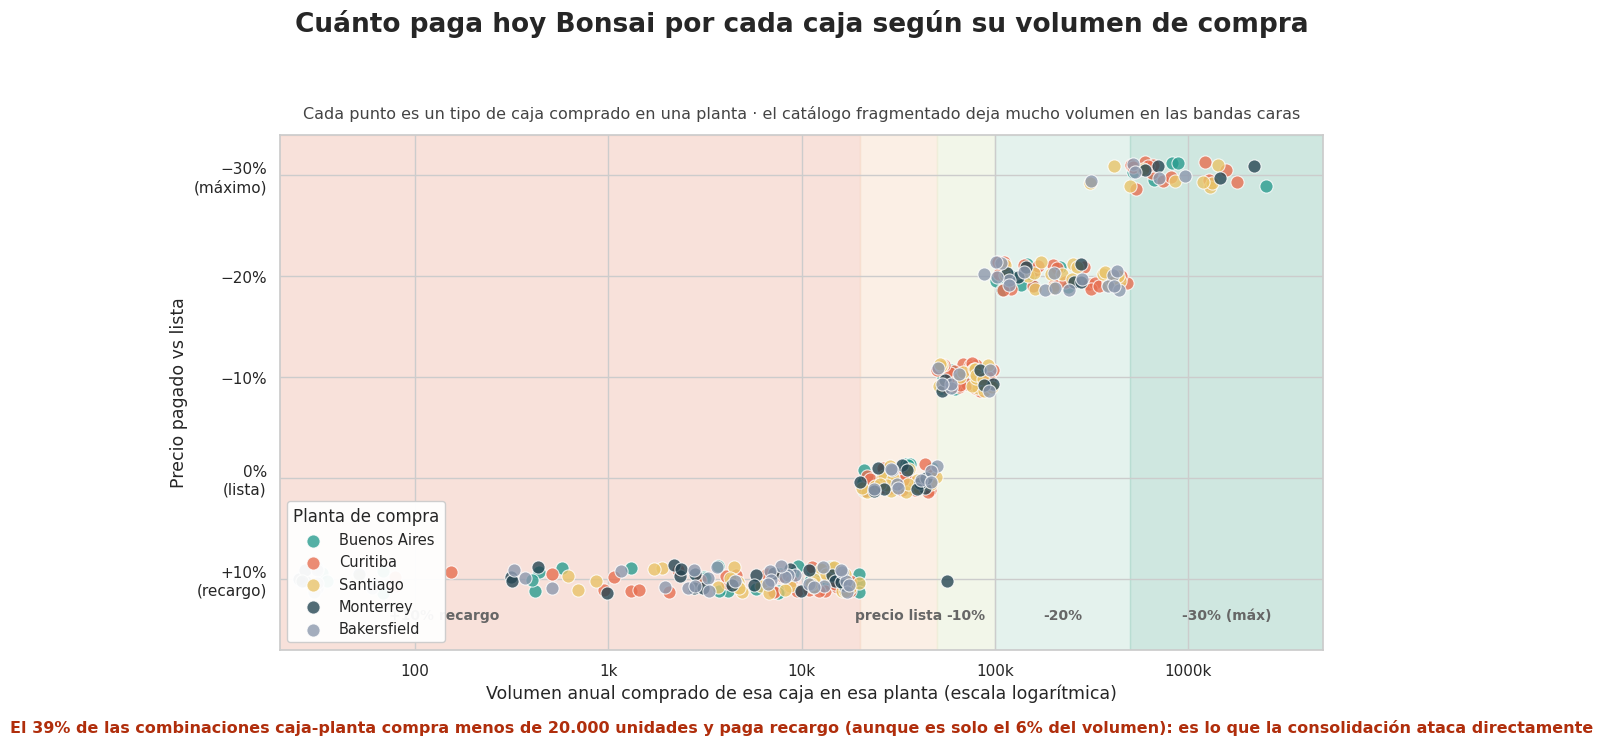

In [17]:
# =====================================================================
# DESCUENTO / RECARGO vs VOLUMEN DE COMPRA (catalogo actual, sin optimizar)
# Unidad correcta: (caja x planta), porque el descuento se aplica por planta.
# Ejecutar con el df maestro en memoria.
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid")

try: d = df.copy()
except NameError: d = pd.read_csv('df_maestro.csv')

plantas = ['buenos_aires', 'curitiba', 'santiago', 'monterrey', 'bakersfield']
nombres = {'buenos_aires': 'Buenos Aires', 'curitiba': 'Curitiba', 'santiago': 'Santiago',
           'monterrey': 'Monterrey', 'bakersfield': 'Bakersfield'}
colores = {'buenos_aires': '#2a9d8f', 'curitiba': '#e76f51', 'santiago': '#e9c46a',
           'monterrey': '#264653', 'bakersfield': '#8d99ae'}

# --- construir un punto por (caja, planta) con volumen > 0 ---
filas = []
for tipo, sub in d.groupby('caja_tipo_id'):
    for p in plantas:
        vol = sub[f'volumen_producto_planta_{p}'].sum()
        if vol > 0:
            desc = float(str(sub[f'descuento_planta_{p}'].iloc[0]).replace('%', '').replace('+', '').replace(' ', ''))
            filas.append(dict(planta=p, volumen=vol, descuento=desc))
pts = pd.DataFrame(filas)

fig, ax = plt.subplots(figsize=(15, 8))
fig.suptitle('Cuánto paga hoy Bonsai por cada caja según su volumen de compra',
             fontsize=19, fontweight='bold', y=0.98)
ax.set_title('Cada punto es un tipo de caja comprado en una planta · el catálogo fragmentado deja mucho volumen en las bandas caras',
             fontsize=11.5, color='#444444', pad=12)

# bandas de tier de fondo (sombreado suave verde=barato, rojo=caro)
bandas = [(1, 20000, '#f4c9bd', '+10% recargo'),
          (20000, 50000, '#f8e3d0', 'precio lista'),
          (50000, 100000, '#e9f0d8', '-10%'),
          (100000, 500000, '#cfe8df', '-20%'),
          (500000, 5e6, '#a8d5c8', '-30% (máx)')]
for lo, hi, col, _ in bandas:
    ax.axvspan(lo, hi, color=col, alpha=0.55, zorder=0)

# puntos con leve jitter vertical para separar solapados dentro del mismo escalon
rng = np.random.default_rng(0)
for p in plantas:
    s = pts[pts['planta'] == p]
    jit = rng.uniform(-1.4, 1.4, len(s))
    ax.scatter(s['volumen'], s['descuento'] + jit, s=90, alpha=0.8, color=colores[p],
               edgecolor='white', linewidth=0.8, label=nombres[p], zorder=3)

ax.set_xscale('log')
ax.set_xlim(20, 5e6)
ax.set_yticks([10, 0, -10, -20, -30])
ax.set_yticklabels(['+10%\n(recargo)', '0%\n(lista)', '−10%', '−20%', '−30%\n(máximo)'], fontsize=11)
ax.invert_yaxis()  # recargo arriba, mejor descuento abajo: "bajar" = mejorar
ax.set_xlabel('Volumen anual comprado de esa caja en esa planta (escala logarítmica)', fontsize=12.5)
ax.set_ylabel('Precio pagado vs lista', fontsize=12.5)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x/1000)}k' if x >= 1000 else f'{int(x)}'))

# etiquetas de banda arriba
for lo, hi, _, txt in bandas:
    xc = np.sqrt(lo * hi)
    ax.text(xc, 14, txt, ha='center', fontsize=10, color='#666', fontweight='bold')

# cuanto volumen cae en recargo
n_rec = (pts['descuento'] > 0).sum()
n_tot = len(pts)
vol_rec = pts.loc[pts['descuento'] > 0, 'volumen'].sum()
vol_tot = pts['volumen'].sum()
ax.text(0.5, -0.16,
        f"El {n_rec/n_tot*100:.0f}% de las combinaciones caja-planta compra menos de 20.000 unidades y paga recargo (aunque es solo el {vol_rec/vol_tot*100:.0f}% del volumen): "
        f"es lo que la consolidación ataca directamente",
        transform=ax.transAxes, ha='center', fontsize=11.5, color='#b02e0c', fontweight='bold')

ax.legend(title='Planta de compra', loc='lower left', fontsize=10.5, framealpha=0.95)
ax.set_ylim(17, -34)
plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.savefig('figura_descuentos_actuales.png', dpi=150, bbox_inches='tight')
plt.show()

# GRAFICOS EDA FINALES

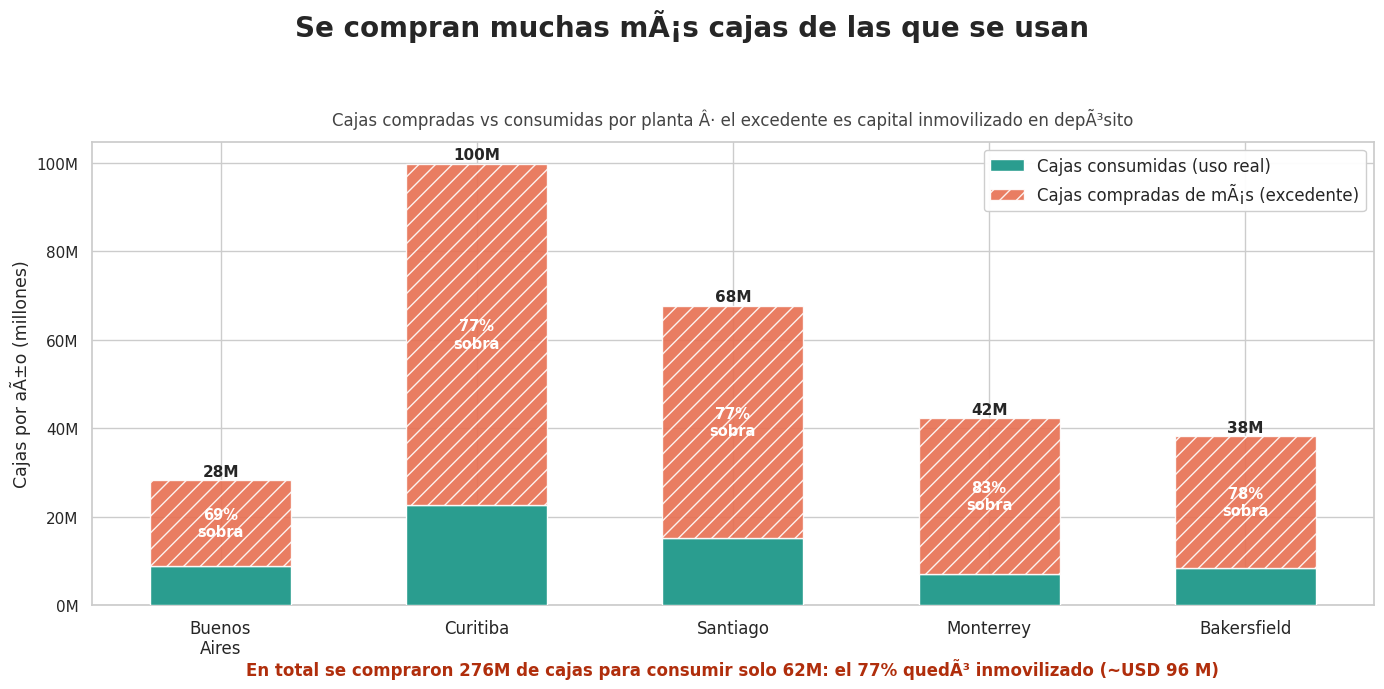

In [18]:
# =====================================================================
# COMPRAS vs CONSUMO DE CAJAS (catalogo historico, sin optimizar)
# Barras = cajas compradas por planta; linea = cajas efectivamente
# consumidas. El excedente (barra por encima de la linea) es capital
# inmovilizado. Ejecutar con el df maestro en memoria.
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
C_TEAL, C_NARANJA, C_ROJO, C_GRIS = '#2a9d8f', '#e76f51', '#b02e0c', '#8d99ae'

try: d = df.copy()
except NameError: d = pd.read_csv('df_maestro.csv')

plantas = ['buenos_aires', 'curitiba', 'santiago', 'monterrey', 'bakersfield']
nombres = {'buenos_aires': 'Buenos\nAires', 'curitiba': 'Curitiba', 'santiago': 'Santiago',
           'monterrey': 'Monterrey', 'bakersfield': 'Bakersfield'}

comprado, consumido = [], []
for p in plantas:
    g = d.groupby('caja_tipo_id').agg(comp=(f'volumen_tipo_planta_{p}', 'first'),
                                      cons=(f'volumen_producto_planta_{p}', 'sum'))
    comprado.append(g['comp'].sum())
    consumido.append(g['cons'].sum())
comprado, consumido = np.array(comprado), np.array(consumido)
sobrante = comprado - consumido

fig, ax = plt.subplots(figsize=(14, 7.5))
fig.suptitle('Se compran muchas mÃ¡s cajas de las que se usan', fontsize=20, fontweight='bold', y=0.97)
ax.set_title('Cajas compradas vs consumidas por planta Â· el excedente es capital inmovilizado en depÃ³sito',
             fontsize=12, color='#444444', pad=12)

x = np.arange(len(plantas))
# barra de consumo (util) + excedente apilado encima (desperdicio)
b1 = ax.bar(x, consumido / 1e6, color=C_TEAL, width=0.55, label='Cajas consumidas (uso real)', zorder=3)
b2 = ax.bar(x, sobrante / 1e6, bottom=consumido / 1e6, color=C_NARANJA, width=0.55, alpha=0.9,
            label='Cajas compradas de mÃ¡s (excedente)', zorder=3, hatch='//')

for i in range(len(plantas)):
    ax.text(x[i], comprado[i] / 1e6 + 1, f'{comprado[i]/1e6:.0f}M', ha='center', fontsize=11, fontweight='bold')
    pct = sobrante[i] / comprado[i] * 100
    ax.text(x[i], (consumido[i] + sobrante[i] / 2) / 1e6, f'{pct:.0f}%\nsobra', ha='center', va='center',
            fontsize=10.5, color='white', fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels([nombres[p] for p in plantas], fontsize=12)
ax.set_ylabel('Cajas por aÃ±o (millones)', fontsize=12.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}M'))
ax.legend(fontsize=12, loc='upper right', framealpha=0.95)

tot_sobra = sobrante.sum()
ax.text(0.5, -0.15,
        f'En total se compraron {comprado.sum()/1e6:.0f}M de cajas para consumir solo {consumido.sum()/1e6:.0f}M: '
        f'el {tot_sobra/comprado.sum()*100:.0f}% quedÃ³ inmovilizado (~USD 96 M)',
        transform=ax.transAxes, ha='center', fontsize=12, color=C_ROJO, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.savefig('figura_sobrestock.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_9958/1772213484.py:52: UserWarning:

Glyph 141 (\x8d) missing from font(s) DejaVu Sans.

/tmp/ipykernel_9958/1772213484.py:53: UserWarning:

Glyph 141 (\x8d) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 141 (\x8d) missing from font(s) DejaVu Sans.



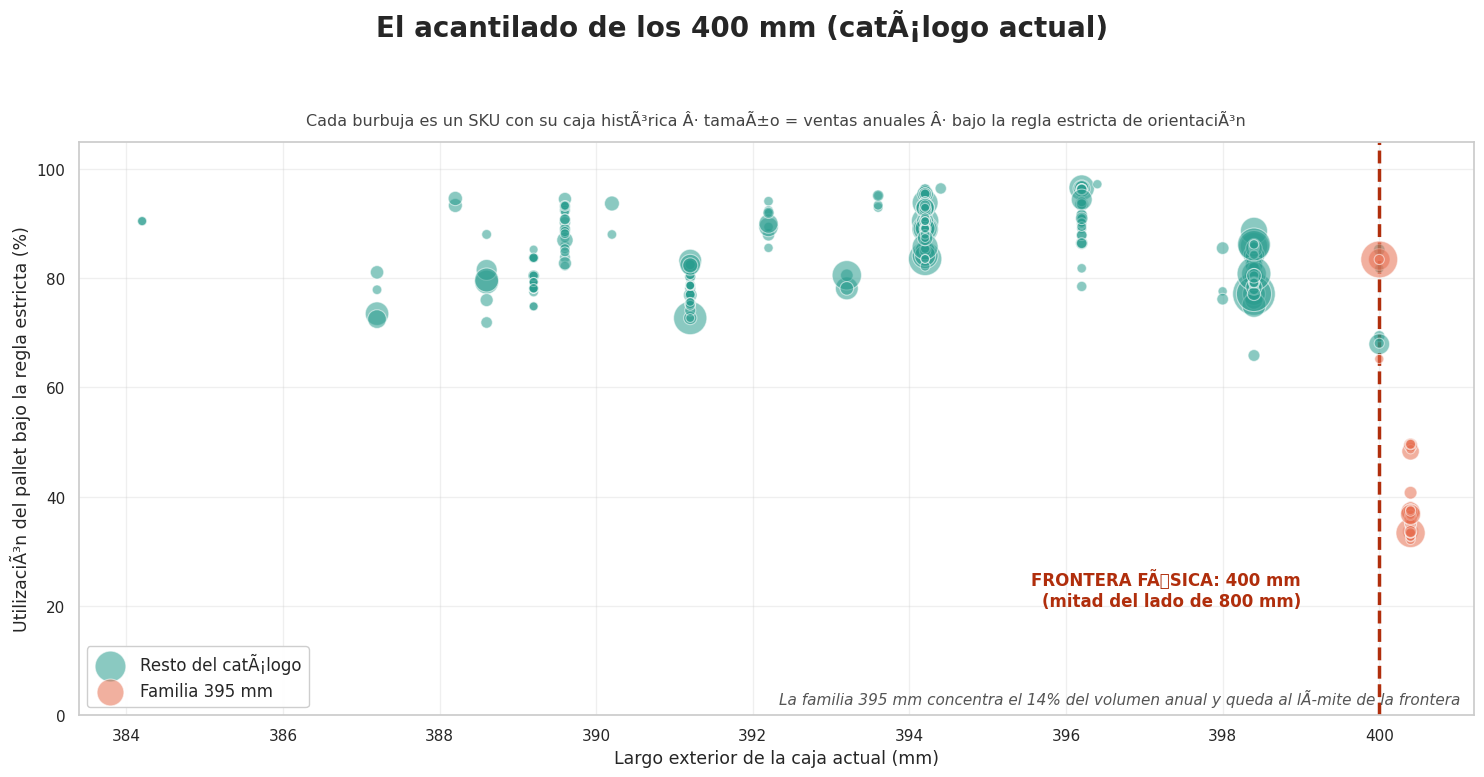

In [19]:
# =====================================================================
# EL ACANTILADO DE LOS 400 mm - CATALOGO HISTORICO (sin optimizar)
# Cada burbuja es un SKU con su caja ACTUAL. Muestra que el apilado
# historico solo cierra tolerando voladizo, y que la familia 395 mm
# queda al limite de los 400 mm. Ejecutar con el df maestro en memoria.
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
C_TEAL, C_NARANJA, C_ROJO = '#2a9d8f', '#e76f51', '#b02e0c'

try: d = df.copy()
except NameError: d = pd.read_csv('df_maestro.csv')

# U_pallet con las cajas ACTUALES, bajo la regla estricta de orientacion
Le, We, He = d['caja_exterior_largo'], d['caja_exterior_ancho'], d['caja_exterior_alto']
cl, cw, cap = (800 // Le).astype(int), (1200 // We).astype(int), (1800 // He).astype(int)
cpp = (cl * cw * cap).replace(0, np.nan)
d = d.assign(U_pallet=cpp * Le * We * He / (1200 * 800 * 1800) * 100,
             fam395=d['caja_interior_largo'] == 395.0)

fig, ax = plt.subplots(figsize=(15, 8))
fig.suptitle('El acantilado de los 400 mm (catÃ¡logo actual)', fontsize=20, fontweight='bold', y=0.97)
ax.set_title('Cada burbuja es un SKU con su caja histÃ³rica Â· tamaÃ±o = ventas anuales Â· bajo la regla estricta de orientaciÃ³n',
             fontsize=11.5, color='#444444', pad=12)

size = 40 + 900 * d['volumen_producto_total'] / d['volumen_producto_total'].max()
for m, col, lab in [(~d['fam395'], C_TEAL, 'Resto del catÃ¡logo'),
                    (d['fam395'], C_NARANJA, 'Familia 395 mm')]:
    ax.scatter(d.loc[m, 'caja_exterior_largo'], d.loc[m, 'U_pallet'], s=size[m], c=col,
               alpha=0.55, edgecolors='white', linewidths=0.8, label=lab, zorder=3)

ax.axvline(400, color=C_ROJO, ls='--', lw=2.5, zorder=2)
ax.text(399, 20, 'FRONTERA FÃSICA: 400 mm\n(mitad del lado de 800 mm)', ha='right', fontsize=12,
        color=C_ROJO, fontweight='bold')
ax.annotate('Hasta 400 mm entran 2 cajas\npor fila: pallet lleno',
            xy=(360, 92), fontsize=12, ha='center', color='#1d6e63', fontweight='bold')
ax.annotate('Desde 401 mm entra 1 sola:\nmedio pallet vacÃ­o',
            xy=(415, 55), fontsize=12, ha='center', color=C_ROJO, fontweight='bold')

ax.set_xlabel('Largo exterior de la caja actual (mm)', fontsize=12.5)
ax.set_ylabel('UtilizaciÃ³n del pallet bajo la regla estricta (%)', fontsize=12.5)
ax.set_ylim(0, 105); ax.grid(alpha=0.3); ax.legend(loc='lower left', fontsize=12, framealpha=0.95)

vol_fam = d.loc[d['fam395'], 'volumen_producto_total'].sum() / d['volumen_producto_total'].sum() * 100
ax.text(0.99, 0.02, f'La familia 395 mm concentra el {vol_fam:.0f}% del volumen anual y queda al lÃ­mite de la frontera',
        transform=ax.transAxes, ha='right', fontsize=11, color='#555', style='italic')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('figura_acantilado_historico.png', dpi=150, bbox_inches='tight')
plt.show()

# Optimizacion de Pallets (1)

Queremos optimizar el empaquetamiento y almacenamiento de los productos como primera rama del proceso de optimizacion. Para esto observemos espacialmnete la relaciones entre tamaños exteriores para cada caja.

## Dimensiones de cajas

En este caso voy a tomar en cuenta el volumen minimo irreductible de cada producto. Veamos que cada producto tiene indicada la utilizacion sobre su caja. Podemos entonces reducir lo mas posible esta "caja virtual" para que asi, podamos conseguir las mayor cantidad de prodcutos que sean compatibles con la menor cantidad de ceajas,

--- FASE 0: MAPEO DE DIMENSIONES INTERNAS (VOLUMEN NETO DEL PRODUCTO) ---

-> Dimensiones internas aisladas. Preparando visualizaciones...

--- VISUALIZACIÓN DEL ESPACIO INTERNO (PRODUCTO DESNUDO) ---




Generando proyecciones 2D del espacio interno...



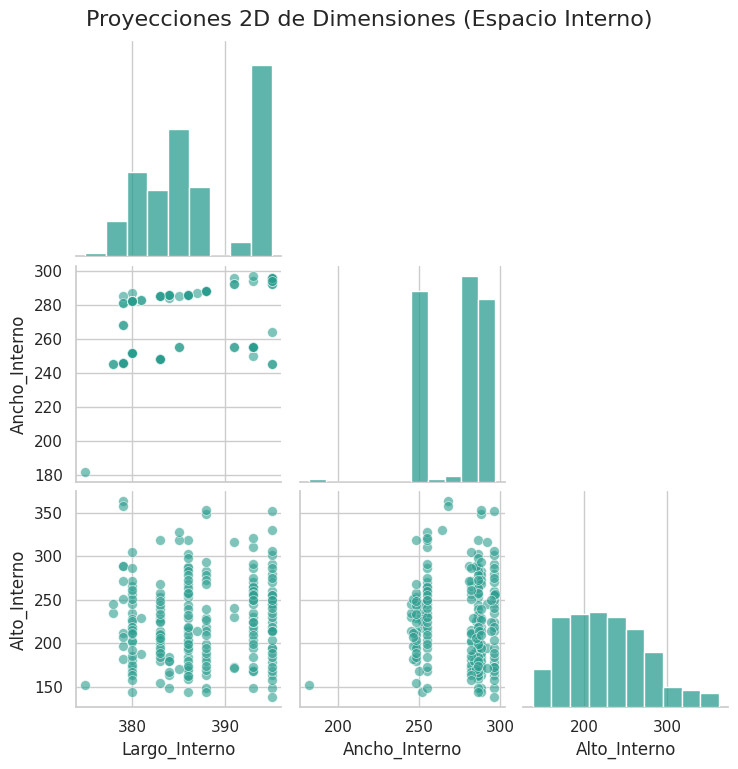

In [20]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

print("--- FASE 0: MAPEO DE DIMENSIONES INTERNAS (VOLUMEN NETO DEL PRODUCTO) ---\n")

# Aislamos el catálogo de cajas para graficar (sin el sesgo del volumen de ventas)
df_entrenamiento = df.drop_duplicates(subset=['caja_tipo_id']).copy()

print("-> Dimensiones internas aisladas. Preparando visualizaciones...\n")
print("--- VISUALIZACIÓN DEL ESPACIO INTERNO (PRODUCTO DESNUDO) ---\n")

# --- 1. VISUALIZACIÓN 3D INTERACTIVA (ESPACIO INTERNO) ---

# Coloreamos por la altura interna
fig_3d_int = px.scatter_3d(
    df_entrenamiento,
    x='caja_interior_largo',
    y='caja_interior_ancho',
    z='caja_interior_alto',
    color='caja_interior_alto',
    color_continuous_scale='Viridis', # Paleta clásica y limpia
    hover_name='caja_tipo_id',
    title='Topología 3D de Cajas (Dimensiones Internas / Producto Neto)',
    opacity=0.8,
    labels={
        'caja_interior_largo': 'Largo Interno (mm)',
        'caja_interior_ancho': 'Ancho Interno (mm)',
        'caja_interior_alto': 'Alto Interno (mm)'
    }
)

fig_3d_int.update_layout(margin=dict(l=0, r=0, b=0, t=40), width=800, height=600)
fig_3d_int.show()

# --- 2. MATRIZ DE PROYECCIONES 2D (PAIRPLOT INTERNO) ---

print("\nGenerando proyecciones 2D del espacio interno...\n")

# Filtramos las columnas geométricas internas
cols_plot_int = ['caja_interior_largo', 'caja_interior_ancho', 'caja_interior_alto']
df_plot_int = df_entrenamiento[cols_plot_int].copy()

# Renombramos las columnas solo para que los ejes del gráfico queden limpios
df_plot_int.columns = ['Largo_Interno', 'Ancho_Interno', 'Alto_Interno']

# Generamos la cuadrícula
sns.set_theme(style="whitegrid")
g_int = sns.pairplot(
    df_plot_int,
    corner=True,
    plot_kws={'alpha': 0.6, 's': 50, 'color': '#2a9d8f'}, # Tono verde/azulado elegante
    diag_kws={'color': '#2a9d8f'}
)

g_int.fig.suptitle("Proyecciones 2D de Dimensiones (Espacio Interno)", y=1.02, fontsize=16)
plt.show()

Los productos parecen estar bastante clusterizados segun dimensiones internas salvo un producto como outlier.

# Motor de optimización final (ejecutado en Spyder)

Tres scripts, en orden de ejecución:

1. **`enum_geometrias.py`** — enumeración exhaustiva del universo de cajas admisibles.
2. **`reform_exacta.py`** — MILP de asignación SKU → tipo de caja con bandas de descuento.
3. **`maestro_solo.py`** — set partitioning sobre el pool acumulado de columnas.

El giro conceptual está en el primero: en vez de muestrear grupos de SKUs y ver qué
geometría sale, se barren las **geometrías** y se lee qué grupo sale. Dada una caja interna
(L, W, H), el conjunto de SKUs que la acepta es determinista —es una consulta de caja en
3D sobre pisos, techos, volumen y compresión— y los (L, W, H) que importan son finitos: el
conjunto admisible solo cambia cuando una dimensión cruza el piso o el techo de algún SKU,
o un umbral de conteo por pallet. Barriendo esos puntos críticos se cubre todo el espacio.

Eso es lo que vuelve tratable el problema y permite resolverlo de forma exacta en lugar de
aproximada.

> Las celdas siguientes no se ejecutan en Colab: dependen de `bonsai_core.py` y de rutas
> locales.


## 1. `enum_geometrias.py` — enumeración exhaustiva del universo de cajas

Barrido vectorizado sobre los puntos críticos de cada eje. Devuelve el pool de conjuntos de SKUs admisibles, evaluados y volcados a `pool_columnas_geom.pkl`.


In [ ]:
# =====================================================================
# ENUM_GEOMETRIAS - enumeracion EXHAUSTIVA por geometria (no por grupo)
# ---------------------------------------------------------------------
# El giro conceptual:
#   paso0 / enum_cliques muestrean GRUPOS y ven que geometria sale.
#   Esto barre GEOMETRIAS y lee que grupo sale. Es exhaustivo.
#
# Por que funciona:
#   Dada una caja interna (L,W,H), el conjunto de SKUs que la aceptan es
#   determinista:
#       piso_ax(s) <= dim_ax <= techo_ax(s)   en los 3 ejes
#       L*W*H >= V(s)                          (volumen)
#       carga(L,W) >= peso(s)*(n_capas-1)      (compresion)
#   O sea: un "box query" en 3D. No hay que buscar nada, se calcula.
#
#   Y los (L,W,H) que importan son FINITOS: el conjunto admisible solo
#   cambia cuando la dimension cruza un piso o un techo de algun SKU, o
#   un umbral de conteo (PALLET/i - G2). Barriendo esos puntos criticos
#   se cubren TODOS los grupos que son "maximales para alguna geometria".
#
#   Toda columna interesante es subconjunto de uno de estos maximales:
#   los maximales son los que mejor tier de packaging consiguen.
#
# Vectorizado con numpy: ~430 x ~440 combinaciones x 427 SKUs.
#
# Uso: python enum_geometrias.py  -> pool_columnas_geom.pkl
# =====================================================================
import os, pickle, time
import numpy as np
import bonsai_core as bc

RAIZ    = r"C:\Users\elfen\Desktop\AUTOMATIZACION DE BUSQUEDA"
PKL_OUT = os.path.join(RAIZ, 'SALIDAS', 'pool_columnas_geom.pkl')
SOLO_K2 = True          # k=1 parte el cpp al medio: casi nunca conviene
MIN_TAM = 1            # tamano minimo de grupo a guardar

T0 = time.time()
def log(m): print(f"[{time.time()-T0:6.0f}s] {m}", flush=True)

S  = list(bc.SKUS)
NS = len(S)
PL, PW, PH = bc.PALLET_L, bc.PALLET_W, bc.PALLET_H
G2 = bc.G2

pisoL  = np.array([bc._PISO[(s, 'L')]  for s in S])
pisoW  = np.array([bc._PISO[(s, 'W')]  for s in S])
pisoH  = np.array([bc._PISO[(s, 'H')]  for s in S])
techL  = np.array([bc._TECHO[(s, 'L')] for s in S])
techW  = np.array([bc._TECHO[(s, 'W')] for s in S])
techH  = np.array([bc._TECHO[(s, 'H')] for s in S])
Vol    = np.array([bc.prod[s]['V']     for s in S])
Peso   = np.array([bc.prod[s]['peso']  for s in S])

def criticos(piso, techo, pallet, imax):
    """Puntos donde el conjunto admisible puede cambiar: techos de SKU
    (arriba sale alguien), pisos (abajo sale alguien) y umbrales de
    conteo pallet/i - G2 (cambia cuantas entran)."""
    pts = set()
    for v in techo:
        pts.add(np.floor(v * 10) / 10)          # justo en el techo
    for v in piso:
        pts.add(np.ceil(v * 10) / 10)           # justo en el piso
    for i in range(1, imax + 1):
        u = np.floor((pallet / i - G2) * 10) / 10
        if u > 0:
            pts.add(u)
    lo, hi = piso.min(), techo.max()
    return sorted(p for p in pts if lo - 1e-9 <= p <= hi + 1e-9)

candL = criticos(pisoL, techL, PL, 3)
candW = criticos(pisoW, techW, PW, 8)
candH = criticos(pisoH, techH, PH, 14)
if SOLO_K2:
    umbral2 = np.floor((PL / 2 - G2) * 10) / 10
    candL = [L for L in candL if L <= umbral2 + 1e-9]
log(f"puntos criticos: L={len(candL)} W={len(candW)} H={len(candH)} "
    f"-> {len(candL)*len(candW)*len(candH):,} geometrias a barrer")

# ------------- barrido -------------
conjuntos = {}          # clave: bytes de la mascara -> frozenset de SKUs
cpps = set()
n_geo = 0
for L in candL:
    k = int(PL // (L + G2))
    if k == 0:
        continue
    okL = (pisoL <= L + 1e-9) & (L <= techL + 1e-9)
    if not okL.any():
        continue
    for W in candW:
        m = int(PW // (W + G2))
        if m == 0:
            continue
        okLW = okL & (pisoW <= W + 1e-9) & (W <= techW + 1e-9)
        if not okLW.any():
            continue
        carga = bc.ECTv * (2.0 * (L + W + 2 * G2) / 1000.0) / bc.GRAV
        LW = L * W
        for H in candH:
            n_cap = int(PH // (H + G2))
            if n_cap == 0:
                continue
            n_geo += 1
            ok = (okLW & (pisoH <= H + 1e-9) & (H <= techH + 1e-9)
                  & (LW * H >= Vol - 1e-6)
                  & (carga >= Peso * (n_cap - 1) - 1e-9))
            c = int(ok.sum())
            if c < MIN_TAM:
                continue
            cpps.add(k * m * n_cap)
            clave = ok.tobytes()
            if clave not in conjuntos:
                conjuntos[clave] = frozenset(S[i] for i in np.flatnonzero(ok))
    log(f"  L={L}: {len(conjuntos):,} conjuntos distintos acumulados")

log(f"barrido: {n_geo:,} geometrias | {len(conjuntos):,} conjuntos admisibles "
    f"distintos | {len(cpps)} valores de cpp: {sorted(cpps)}")

# ------------- evaluar y volcar -------------
columnas = {}
for s in S:
    r = bc.evaluar([s])
    if r:
        columnas[frozenset([s])] = r[0]
n_inf = 0
for i, g in enumerate(conjuntos.values()):
    if g in columnas:
        continue
    r = bc.evaluar(g)
    if r is None:
        n_inf += 1
        continue
    columnas[g] = r[0]
    if len(bc._cache) > 400_000:
        bc._cache.clear()
    if (i + 1) % 2000 == 0:
        log(f"  evaluados {i+1:,}/{len(conjuntos):,}")

log(f"{len(columnas):,} columnas ({n_inf} conjuntos infactibles al evaluar)")
tam = [len(g) for g in columnas if len(g) > 1]
if tam:
    log(f"tamanos de grupo: min {min(tam)} | mediana {sorted(tam)[len(tam)//2]} "
        f"| max {max(tam)}")

with open(PKL_OUT, 'wb') as fh:
    pickle.dump(columnas, fh)
log(f"volcado en {PKL_OUT}")
log("ahora: pricing_reforzado.py (o maestro_solo.py) para que el LP y el")
log("MILP usen estas columnas exhaustivas por geometria.")

## 2. `reform_exacta.py` — MILP de asignación SKU → tipo de caja

Variables binarias de asignación más variables de banda de descuento por (tipo, planta). Incluye poda por dominancia sobre los tipos candidatos y cota LP relajada antes de resolver el entero.


In [ ]:
# =====================================================================
# REFORM_EXACTA - asignacion SKU -> tipo de caja (MILP exacto)
# ---------------------------------------------------------------------
# Modelo:
#   Tipos candidatos = las mascaras admisibles del barrido exhaustivo
#   (pool_columnas_geom.pkl) + singletons. Para cada mascara A, evaluar(A)
#   da su cpp maximo y dims. Variables:
#     x[s,t] = 1 si el SKU s usa el tipo t   (solo si s esta en A_t)
#     v[t,pl,b], z[t,pl,b] = volumen y seleccion de banda de descuento
#   min  sum F[s,t]*x[s,t] + sum PB*f_b*v[t,pl,b]
#   s.a. cada SKU en exactamente un tipo
#        volumen agrupado del tipo = suma de bandas
#        una banda activa por (t,pl), volumen dentro de la banda elegida
#   donde F[s,t] = 150 * sum_pl ceil(dem_s[pl]/cpp_t)   (constante)
#
# Poda por dominancia: si A esta contenida en A' y cpp_A <= cpp_A',
# el tipo A sobra (mover sus SKUs a A' nunca empeora flete y solo
# agrupa mas volumen para packaging).
#
# Al final exporta con bc.exportar: evaluar() recalcula las dims optimas
# del subconjunto realmente asignado (solo puede subir el cpp) y
# verificar_csv audita todo.
#
# Uso: python reform_exacta.py
# =====================================================================
import os, pickle, time
import numpy as np
import scipy.sparse as sp
from scipy.optimize import milp, LinearConstraint as LC, Bounds
import bonsai_core as bc

RAIZ    = r"C:\Users\elfen\Desktop\AUTOMATIZACION DE BUSQUEDA"
PKL_GEO = os.path.join(RAIZ, 'SALIDAS', 'pool_columnas_geom.pkl')
COTA    = 188087694.36
CSV_OUT = os.path.join(RAIZ, 'MEJOR_reform.csv')
TIME_LIMIT = 5400            # 90 min; subilo si lo dejas de noche
GAP        = 0.0             # 0 = optimo certificado

T0 = time.time()
def log(m): print(f"[{time.time()-T0:6.0f}s] {m}", flush=True)

PLTS = bc.plantas
BANDAS = [(0.0, 20000.0, 1.10), (20000.0, 50000.0, 1.00),
          (50000.0, 100000.0, 0.90), (100000.0, 500000.0, 0.80)]
# la ultima banda se cierra con el volumen total de la planta
DEM_PL = {pl: sum(bc.prod[s]['dem'][pl] for s in bc.SKUS) for pl in PLTS}

# ---------------- tipos candidatos ----------------
with open(PKL_GEO, 'rb') as fh:
    geo = pickle.load(fh)
mascaras = set(k for k in geo if len(k) >= 2)
for s in bc.SKUS:
    mascaras.add(frozenset([s]))
log(f"mascaras brutas: {len(mascaras):,}")

tipos = []                    # (frozenset, cpp, costo_eval)
for A in mascaras:
    r = bc.evaluar(A)
    if r is None:
        continue
    L, W, H = r[1]
    cpp = (int(bc.PALLET_L // (L + bc.G2)) * int(bc.PALLET_W // (W + bc.G2))
           * int(bc.PALLET_H // (H + bc.G2)))
    tipos.append((A, cpp))
# poda por dominancia (contenido en otro con cpp >= el propio)
tipos.sort(key=lambda t: -len(t[0]))
vivos = []
for A, c in tipos:
    if any(A < B and c <= cB for B, cB in vivos):
        continue
    vivos.append((A, c))
tipos = vivos
log(f"tipos tras poda por dominancia: {len(tipos):,}")

# ---------------- indices de variables ----------------
# x: (s,t) con s en A_t
xs = []                       # lista de (i_sku, j_tipo, F_st)
for j, (A, cpp) in enumerate(tipos):
    for s in A:
        F = 150.0 * sum(-(-bc.prod[s]['dem'][pl] // cpp)   # ceil
                        for pl in PLTS if bc.prod[s]['dem'][pl] > 0)
        xs.append(( bc.SKUS.index(s), j, F ))
NX = len(xs)
log(f"variables x: {NX:,}")

# (t,pl) con volumen posible
tpl = []
for j, (A, cpp) in enumerate(tipos):
    for p_i, pl in enumerate(PLTS):
        if any(bc.prod[s]['dem'][pl] > 0 for s in A):
            tpl.append((j, p_i))
NB = len(BANDAS) + 1          # 5 bandas
NTP = len(tpl)
log(f"pares (tipo,planta): {NTP:,} -> {NTP*NB:,} v + {NTP*NB:,} z")

# layout: [ x (NX) | v (NTP*NB) | z (NTP*NB) ]
OFF_V = NX
OFF_Z = NX + NTP * NB
NVAR  = NX + 2 * NTP * NB
TPL_IDX = {tp: i for i, tp in enumerate(tpl)}
IDX_S = {s: i for i, s in enumerate(bc.SKUS)}

def vi(itp, b): return OFF_V + itp * NB + b
def zi(itp, b): return OFF_Z + itp * NB + b

# ---------------- objetivo ----------------
cobj = np.zeros(NVAR)
for k, (i_s, j, F) in enumerate(xs):
    cobj[k] = F
for itp, (j, p_i) in enumerate(tpl):
    for b in range(NB):
        f = BANDAS[b][2] if b < len(BANDAS) else 0.70
        cobj[vi(itp, b)] = bc.PB * f

# ---------------- restricciones ----------------
rows, cols, vals, lb, ub = [], [], [], [], []
nr = 0
def add_row(pares, lo, hi):
    global nr
    for c, v in pares:
        rows.append(nr); cols.append(c); vals.append(v)
    lb.append(lo); ub.append(hi); nr += 1

# 1) cada SKU exactamente un tipo
por_sku = {i: [] for i in range(len(bc.SKUS))}
for k, (i_s, j, F) in enumerate(xs):
    por_sku[i_s].append(k)
for i_s, ks in por_sku.items():
    add_row([(k, 1.0) for k in ks], 1.0, 1.0)

# 2) volumen del tipo en la planta = suma de bandas
x_por_tj = {}
for k, (i_s, j, F) in enumerate(xs):
    x_por_tj.setdefault(j, []).append((k, i_s))
for itp, (j, p_i) in enumerate(tpl):
    pl = PLTS[p_i]
    pares = [(k, bc.prod[bc.SKUS[i_s]]['dem'][pl])
             for k, i_s in x_por_tj[j]
             if bc.prod[bc.SKUS[i_s]]['dem'][pl] > 0]
    pares += [(vi(itp, b), -1.0) for b in range(NB)]
    add_row(pares, 0.0, 0.0)

# 3) una banda por (t,pl); v dentro de la banda elegida
VOLMAX = {}
for itp, (j, p_i) in enumerate(tpl):
    pl = PLTS[p_i]
    VOLMAX[itp] = sum(bc.prod[s]['dem'][pl] for s in tipos[j][0])

n_fijas = 0
for itp, (j, p_i) in enumerate(tpl):
    Mtp = VOLMAX[itp]
    add_row([(zi(itp, b), 1.0) for b in range(NB)], 1.0, 1.0)
    for b in range(NB):
        loB = BANDAS[b][0] if b < len(BANDAS) else 500000.0
        hiB = BANDAS[b][1] if b < len(BANDAS) else Mtp
        hiB = min(hiB, Mtp)
        if loB > Mtp + 1e-9:
            add_row([(zi(itp, b), 1.0)], 0.0, 0.0)
            add_row([(vi(itp, b), 1.0)], 0.0, 0.0)
            n_fijas += 1
            continue
        add_row([(vi(itp, b), 1.0), (zi(itp, b), -hiB)], -np.inf, 0.0)
        add_row([(vi(itp, b), -1.0), (zi(itp, b), loB)], -np.inf, 0.0)
log(f"bandas fijadas en 0 por inalcanzables: {n_fijas:,}")





A = sp.csc_matrix((vals, (rows, cols)), shape=(nr, NVAR))
log(f"matriz: {nr:,} filas x {NVAR:,} vars ({A.nnz:,} nnz)")

integ = np.zeros(NVAR)
integ[:NX] = 1
integ[OFF_Z:] = 1
lo = np.zeros(NVAR); hi = np.ones(NVAR)
hi[OFF_V:OFF_Z] = np.inf



# ---------------- cota inferior antes de sufrir ----------------
log("cota LP relajada (rapida)...")
res_lp = milp(c=cobj, constraints=[LC(A, np.array(lb), np.array(ub))],
              integrality=np.zeros(NVAR), bounds=Bounds(lo, hi),
              options={'time_limit': 1000})
if res_lp.x is not None:
    cLP = float(res_lp.fun)
    log(f"COTA LP: {cLP:,.2f} | score {bc.score(cLP):+.5f}%")
    log(f"  vs tu incumbente {COTA:,.2f}  -> margen {COTA-cLP:,.2f}")
    log(f"  vs lider        188,079,128   -> {cLP-188079128:+,.2f}")
else:
    log("LP no cerro en 900s")

# ---------------- latido de progreso ----------------
import threading
_fin = threading.Event()
_TM = time.time()
def _latido():
    while not _fin.wait(30):
        t = time.time() - _TM
        print(f"    ... MILP vivo {t:6.0f}s / {TIME_LIMIT}s "
              f"({100*t/TIME_LIMIT:5.1f}% del limite)", flush=True)
threading.Thread(target=_latido, daemon=True).start()

log(f"resolviendo MILP (time_limit {TIME_LIMIT}s, gap {GAP})...")
res = milp(c=cobj, constraints=[LC(A, np.array(lb), np.array(ub))],
           integrality=integ, bounds=Bounds(lo, hi),
           options={'time_limit': TIME_LIMIT, 'mip_rel_gap': GAP,
                    'disp': True})
_fin.set()
# log(f"resolviendo (time_limit {TIME_LIMIT}s, gap {GAP})...")
# res = milp(c=cobj, constraints=[LC(A, np.array(lb), np.array(ub))],
#            integrality=integ, bounds=Bounds(lo, hi),
#            options={'time_limit': TIME_LIMIT, 'mip_rel_gap': GAP,
#                     'disp': True})




log(f"status: {res.message[:70]}")
if res.x is None:
    log("sin solucion en el limite de tiempo")
    raise SystemExit
val_modelo = float(res.fun)
log(f"objetivo modelo: {val_modelo:,.2f} | score {bc.score(val_modelo):+.5f}%")
if hasattr(res, 'mip_dual_bound'):
    log(f"cota dual: {res.mip_dual_bound * 1.0:,.2f} (gap de certificacion)")

# ---------------- reconstruir, re-evaluar EXACTO y exportar ----------------
asig = {}
for k, (i_s, j, F) in enumerate(xs):
    if res.x[k] > 0.5:
        asig.setdefault(j, set()).add(bc.SKUS[i_s])
grupos = [frozenset(g) for g in asig.values()]
costo_real = bc.costo_grupos(grupos)     # evaluar() re-optimiza dims por grupo
log(f"costo REAL (bonsai_core): {costo_real:,.2f} | "
    f"score {bc.score(costo_real):+.5f}% | {len(grupos)} tipos")

if costo_real < COTA - 1e-6:
    bc.exportar(grupos, CSV_OUT)
    bc.verificar_csv(CSV_OUT)
    log(f">> MEJORA guardada en {CSV_OUT}")
else:
    log(f"no supera tu cota {COTA:,.2f}; si el solver certifico optimo, este")
    log("es el techo del espacio de tipos enumerado.")


## 3. `maestro_solo.py` — set partitioning sobre el pool acumulado

Junta todas las columnas generadas, aplica una reducción por dominancia que no pierde optimalidad y resuelve la partición exacta con gap 0 %.


In [ ]:
# =====================================================================
# MAESTRO SOLO - resuelve el set partitioning sobre el pool acumulado
# ---------------------------------------------------------------------
# NO corre paso 0. Solo junta todos los pool_columnas_*.pkl (SALIDAS +
# PROCESADOS), aplica una reduccion segura por dominancia, y resuelve.
#
# Dominancia: si todos los SKUs de un grupo g tienen caja individual
# factible y costo(g) >= suma de sus costos individuales, entonces g
# NUNCA puede aparecer en una solucion optima (partirlo en singletons
# cubre lo mismo mas barato). Se descarta sin perder optimalidad.
#
# Uso: python maestro_solo.py
# =====================================================================
import os, glob, pickle, time
import numpy as np
import scipy.sparse as _sp
from scipy.optimize import milp as _milp, LinearConstraint as _LC, Bounds as _Bnd
import bonsai_core as bc

RAIZ  = r"C:\Users\elfen\Desktop\AUTOMATIZACION DE BUSQUEDA"
DIRS  = [os.path.join(RAIZ, 'SALIDAS'), os.path.join(RAIZ, 'PROCESADOS')]
COTA  = 188087694.36                       # tu mejor costo actual
CSV_OUT = os.path.join(RAIZ, 'MEJOR_maestro_enum.csv')
TIME_LIMIT = 1800

_IDX = {s: i for i, s in enumerate(bc.SKUS)}
t0 = time.time()

# ---- singletons (siempre en el pool: garantizan factibilidad) ----
SOLO, columnas = {}, {}
for s in bc.SKUS:
    r = bc.evaluar([s])
    if r:
        SOLO[s] = r[0]
        columnas[frozenset([s])] = r[0]
print(f"[*] {len(SOLO)}/{len(bc.SKUS)} SKUs con caja individual factible")

# ---- juntar el pool ----
leidos = 0
for d in DIRS:
    for pk in glob.glob(os.path.join(d, 'pool_columnas_*.pkl')):
        try:
            with open(pk, 'rb') as fh:
                dd = pickle.load(fh)
            for k, v in dd.items():
                if k not in columnas:
                    columnas[k] = v[0] if isinstance(v, tuple) else v
            leidos += 1
            print(f"    + {os.path.basename(pk)[:55]:<55} pool {len(columnas):,}")
        except Exception as e:
            print(f"    !! {os.path.basename(pk)}: {repr(e)[:50]}")
print(f"[*] {leidos} pkl leidos | {len(columnas):,} columnas brutas")

# ---- reduccion por dominancia ----
antes = len(columnas)
columnas = {k: c for k, c in columnas.items()
            if len(k) == 1 or not all(s in SOLO for s in k)
            or c < sum(SOLO[s] for s in k) - 1e-6}
print(f"[*] dominancia: {antes:,} -> {len(columnas):,} columnas "
      f"({antes-len(columnas):,} descartadas)")

# ---- resolver ----
cols = list(columnas.keys()); nC = len(cols)
fil, co = [], []
for j, c in enumerate(cols):
    for s in c:
        fil.append(_IDX[s]); co.append(j)
A = _sp.csc_matrix((np.ones(len(fil)), (fil, co)), shape=(len(bc.SKUS), nC))
cv = np.array([columnas[k] for k in cols])
esc = 1e6

print(f"[*] resolviendo MILP: {nC:,} columnas x {len(bc.SKUS)} SKUs "
      f"(cota {COTA:,.2f})...")
res = _milp(c=cv,
            constraints=[_LC(A, lb=1, ub=1),
                         _LC((cv / esc).reshape(1, -1), lb=-np.inf, ub=COTA / esc)],
            integrality=np.ones(nC), bounds=_Bnd(0, 1),
            options={'time_limit': TIME_LIMIT, 'mip_rel_gap': 0})

print(f"[*] {time.time()-t0:.0f}s | status: {res.message[:70]}")
if res.x is None:
    print("[!] INFACTIBLE bajo la cota: el pool no tiene nada mejor que")
    print(f"    {COTA:,.2f}. Hacen falta columnas nuevas (tamano >=5 / pricing).")
else:
    obj = float(res.fun)
    grupos = [cols[i] for i in range(nC) if res.x[i] > 0.5]
    cub = [s for g in grupos for s in g]
    ok = len(cub) == len(bc.SKUS) and len(set(cub)) == len(bc.SKUS)
    print(f"[*] costo {obj:,.2f} | score {bc.score(obj):+.5f}% | "
          f"{len(grupos)} cajas | particion valida: {ok}")
    if ok and obj < COTA - 1e-6:
        bc.exportar(grupos, CSV_OUT)
        bc.verificar_csv(CSV_OUT)
        print(f"[*] MEJORA guardada en {CSV_OUT}")

# EXTRAPOLACION PRODUCTOS NUEVOS

🔄 Protocolo de Asignación (Extrapolación a Nuevos Productos)

Ante el lanzamiento de un nuevo SKU, este protocolo evalúa automáticamente si el producto puede alojarse en el catálogo optimizado existente o si requiere la creación de un nuevo tipo de caja, priorizando la reducción de inventario.

El algoritmo itera sobre cada caja activa del catálogo y la somete a un "embudo de 4 filtros":

1.  **Filtro de Fit (Encaje Físico):** Descarta instantáneamente cualquier caja cuyas dimensiones internas sean menores a las del nuevo producto.
2.  **Filtro de Headspace (Holgura):** De las cajas que pasaron el Fit, rechaza aquellas donde el espacio vacío supere el porcentaje máximo permitido según su grosor (o el techo de 40mm), evitando colapsos por falta de apoyo interno.
3.  **Filtro ECT (Resistencia):** Para las cajas sobrevivientes, calcula el peso de la columna apilada en el pallet estándar. Si este peso supera la Carga Máxima de la caja (basada en su ECT y perímetro), la caja es rechazada.
4.  **Optimización Financiera:** Si múltiples cajas aprueban los tres filtros físicos, el protocolo calcula el costo logístico marginal ($Costo_{Pack} + Costo_{Flete}$) de usar cada una.

**Veredicto:** El sistema asigna el producto a la caja válida que genere el menor costo. Si ninguna caja logra atravesar los filtros físicos, el protocolo emite un "Rechazo Total" y justifica matemáticamente la creación de un nuevo molde.

In [25]:
# =====================================================================
# 9. ENTREGABLE: PROTOCOLO DE ASIGNACIÓN PARA NUEVOS PRODUCTOS
# =====================================================================
def protocolo_asignacion_nuevo_producto(nuevo_prod, catalogo_optimizado):
    """
    Evalúa si un nuevo producto puede ser asignado a una caja del catálogo optimizado existente
    sin violar las restricciones físicas (Fit, Headspace, Compresión ECT).

    nuevo_prod: dict con {'L': float, 'W': float, 'H': float, 'peso': float, 'demandas_plantas': dict}
    catalogo_optimizado: dict de cajas activas (ej. la variable cajas_activas del motor)
    """
    mejor_caja_id = None
    mejor_costo_marginal = float('inf')
    razones_rechazo = {}

    for id_caja, datos_caja in catalogo_optimizado.items():
        # Asumimos que los datos de la caja optimizada ya tienen su L, W, H y grosor definidos
        # Extraemos el grosor de la primera iteración válida (o del df final)
        res = evaluar_fusion(datos_caja['productos_contenidos'])
        if res is None:
            raise ValueError("Caja sin configuracion fisica valida: revisar restricciones")
        grosor_caja, cpp_base, L_caja, W_caja, H_caja = res

        # 1. RESTRICCIÓN DE FIT (¿Entra el producto en la caja?)
        if nuevo_prod['L'] > L_caja or nuevo_prod['W'] > W_caja or nuevo_prod['H'] > H_caja:
            razones_rechazo[id_caja] = "Falla Fit (Producto más grande que la caja)"
            continue

        # 2. RESTRICCIÓN DE HEADSPACE (¿Sobra demasiado espacio?)
        hs_pct = propiedades_carton[grosor_caja]["hs_max_pct"]
        if (L_caja - nuevo_prod['L']) > min(40.0, L_caja * hs_pct) or \
           (W_caja - nuevo_prod['W']) > min(40.0, W_caja * hs_pct) or \
           (H_caja - nuevo_prod['H']) > min(40.0, H_caja * hs_pct):
            razones_rechazo[id_caja] = "Falla Headspace (Demasiado espacio vacío)"
            continue

        # 3. RESTRICCIÓN DE ECT Y COMPRESIÓN (¿Se aplasta el pallet?)
        L_ext, W_ext, H_ext = L_caja + 2*grosor_caja, W_caja + 2*grosor_caja, H_caja + 2*grosor_caja
        ect = propiedades_carton[grosor_caja]["ect"]
        carga_max = (ect * (2 * (L_ext + W_ext) / 1000.0)) / GRAVEDAD

        cajas_L = int(800 // L_ext)
        cajas_W = int(1200 // W_ext)
        capas   = int(1800 // H_ext)
        cpp = max(1, cajas_L * cajas_W * capas)

        if carga_max < nuevo_prod['peso'] * (capas - 1):
            razones_rechazo[id_caja] = "Falla ECT (No soporta el peso en la columna del pallet)"
            continue

        # 4. EVALUACIÓN FINANCIERA (Si pasó las físicas, calculamos el costo de elegir esta caja)
        volumen_nuevo = sum(nuevo_prod['demandas_plantas'].values())
        costo_pack = propiedades_carton[grosor_caja]["precio_base"] * volumen_nuevo
        costo_flete = sum(math.ceil(nuevo_prod['demandas_plantas'][pl] / cpp) * COSTO_FLETE_LOCAL
                          for pl in plantas if nuevo_prod['demandas_plantas'][pl] > 0)

        costo_total = costo_pack + costo_flete

        if costo_total < mejor_costo_marginal:
            mejor_costo_marginal = costo_total
            mejor_caja_id = id_caja

    # --- DECISIÓN FINAL ---
    print(f"\n--- PROTOCOLO DE ASIGNACIÓN: NUEVO PRODUCTO ---")
    print(f"Dimensiones: {nuevo_prod['L']}x{nuevo_prod['W']}x{nuevo_prod['H']} mm | Peso: {nuevo_prod['peso']} kg")

    if mejor_caja_id:
        print(f"✅ VEREDICTO: ASIGNAR A CAJA EXISTENTE ({mejor_caja_id})")
        print(f"-> Costo logístico marginal estimado: USD {mejor_costo_marginal:,.2f}")
        return mejor_caja_id
    else:
        print(f"❌ VEREDICTO: RECHAZO TOTAL. CREAR NUEVO SKU DE CAJA.")
        print("-> Justificación: El producto no cumple las restricciones físicas del catálogo actual.")
        # Muestra un par de ejemplos de por qué falló
        muestras_fallas = list(razones_rechazo.values())[:3]
        print(f"-> Ejemplos de fallos en el catálogo: {muestras_fallas}")
        return "NUEVO_SKU"

# =====================================================================
# EJEMPLO DE USO (Para probar la función):
# =====================================================================

producto_test = {
    'L': 250.0, 'W': 150.0, 'H': 100.0,
    'peso': 2.5,
    'demandas_plantas': {'buenos_aires': 5000, 'curitiba': 2000, 'santiago': 0, 'monterrey': 1000, 'bakersfield': 0}
}
resultado = protocolo_asignacion_nuevo_producto(producto_test, cajas_activas)



--- PROTOCOLO DE ASIGNACIÓN: NUEVO PRODUCTO ---
Dimensiones: 250.0x150.0x100.0 mm | Peso: 2.5 kg
❌ VEREDICTO: RECHAZO TOTAL. CREAR NUEVO SKU DE CAJA.
-> Justificación: El producto no cumple las restricciones físicas del catálogo actual.
-> Ejemplos de fallos en el catálogo: ['Falla Headspace (Demasiado espacio vacío)', 'Falla Headspace (Demasiado espacio vacío)', 'Falla Headspace (Demasiado espacio vacío)']
